<a href="https://colab.research.google.com/github/kumar-c-git-hub/LinkedIn-Job-Postings/blob/main/LinkedIn_Job_Postings_Analytics_(USA).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

###Project Title

##LinkedIn Job Postings Analytics (USA)

###Domain

##HR Analytics & Recruitment

###Objective

*   Analyze compensation trends across job domains, experience levels, and locations to benchmark competitive salaries

*   Measure job posting effectiveness by correlating applies, views, and sponsored status to optimize recruitment spend

*   Identify high-demand remote roles by work_type and job_domain to inform hybrid work policies

*   Benchmark recruitment performance using applies-to-views ratios by industry and geography

* Analyze application behavior and job demand patterns across industries, company size, and benefits

*   Track geographic hiring hotspots by mapping job_location patterns to prioritize regional recruitment strategies

###Dataset information

Source : data.world Open Data Platform

Location : United States (US-Wide Coverage)

Year/Timeline : 2023-2024 (Analysis covers full dataset period)

#**Stage 1**
###**Problem Definition and Dataset Selection**

In [1]:
#Import Libraries

# DATA ANALYSIS LIBRARIES
import pandas as pd    # Data manipulation & analysis
import numpy as np     # Numerical operations

# VISUALIZATION LIBRARIES
import matplotlib.pyplot as plt  # Core plotting
import seaborn as sns    # Statistical visualizations
import plotly.express as px



In [2]:
#Loading the Data Set from git hub

url = "https://raw.githubusercontent.com/kumar-c-git-hub/LinkedIn-Job-Postings/main/Raw%20Data/LinkedIn%20Job%20Postings.xlsx"

raw_data = pd.read_excel(url, sheet_name=None, engine="openpyxl")

print("LinkedIn Job Posting Dataset successfully loaded!\n")

print("Sheet contantains", raw_data.keys()) #Viewing sheet name from the excel file

LinkedIn Job Posting Dataset successfully loaded!

Sheet contantains dict_keys(['posting', 'benefits', 'company'])


In [3]:
# Extracting each sheet into separate DataFrames
posting = raw_data["posting"]
benefits = raw_data["benefits"]
company = raw_data["company"]

In [4]:
# Looping through all sheets and displaying the data
for name in raw_data:
    print("Sheet Name:", name)
    display(raw_data[name])

Sheet Name: posting


,job_id,title,description,pay_period,work_type,job_location,applies,remote_allowed,views,level,sponsored,compensation,job_domain,company_id,ben_pack_id
0,903408693,Office Associate,Provide clerical and administrative support to...,YEARLY,Full-time,"Albany, GA",5,False,49,NaN,True,42000.0,Administration,3894635,1.0
1,1029078768,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,HOURLY,Part-time,"Muskegon, MI",0,False,4,NaN,False,104000.0,Healthcare,61469,1.0
2,1657978824,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",MONTHLY,Contract,"Texas, United States",0,True,0,NaN,False,144000.0,Other,89350959,1.0
3,2148434033,Contract Bilingual Recruiter,"Location: Phoenix, AZ 85006---- IN OFFICE JOB ...",YEARLY,Contract,"Phoenix, AZ",0,False,0,Associate,False,65000.0,Human Resources,1082195,1.0
4,2148434586,"Manager, Salesforce Platform",Invitation Homes is a fast-paced evolving publ...,YEARLY,Full-time,"New Hampshire, United States",0,False,0,Mid-Senior level,False,170976.0,Information Technology,2780388,113.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,3701373385,Sales Manager,"Sales ManagerTexas, US $60,000â€“$70,000OTE $2...",YEARLY,Full-time,"Texas, United States",7,True,56,Mid-Senior level,False,70000.0,Business Development,18312164,1.0
6324,3701373427,Design Intern,Looking to redefine the skyline or to be a par...,HOURLY,Internship,"Miramar, FL",2,False,20,Mid-Senior level,False,49691.2,Design,1321042,1.0
6325,3701373432,Continuous Improvement Specialist,Continuous Improvement Specialist Opportunity!...,YEARLY,Full-time,"Mississippi, United States",11,False,28,Mid-Senior level,True,200000.0,Management,2121817,128.0
6326,3701373493,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,YEARLY,Full-time,"Torrance, CA",4,False,29,Mid-Senior level,False,105200.0,Marketing,5619,47.0


Sheet Name: benefits


,ben_pack_id,disability,401k,commuter,medical,vision,dental,tuition,maternity,paternity,pension,student_loan,child_care
0,1,False,False,False,False,False,False,False,False,False,False,False,False
1,2,False,False,False,False,False,False,False,False,False,False,False,True
2,3,False,False,False,False,False,False,False,False,False,False,True,False
3,4,False,False,False,False,False,False,False,False,False,True,False,False
4,5,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,169,True,True,True,True,True,True,True,True,True,False,False,False
169,170,True,True,True,True,True,True,True,True,True,False,False,True
170,171,True,True,True,True,True,True,True,True,True,False,True,False
171,172,True,True,True,True,True,True,True,True,True,True,True,False


Sheet Name: company


,company_id,company_name,employees,followers,industry,state,country,city,zip
0,1009,IBM,316130,16114398,Information Technology & Services,NY,US,"Armonk, New York",10504
1,1016,GE HealthCare,53495,2060378,Hospital & Health Care,NaN,US,Chicago,NaN
2,1025,Hewlett Packard Enterprise,70995,3646359,Information Technology & Services,Texas,US,Houston,77389
3,1043,Siemens,213470,6436671,Industrial Automation,NaN,DE,Munich,80333
4,1063,Cisco,99680,6190614,Computer Software,CA,US,San Jose,95134
...,...,...,...,...,...,...,...,...,...
2671,98530571,Savvy Life Connections,0,1,NaN,FL,US,Winter Haven,33880
2672,98531368,JL Klein Executive Search,2,1170,NaN,FL,US,Miami,33139
2673,98550552,INK Creative Strategies,0,29,NaN,NJ,US,Somerville,08876
2674,98556556,Port City Animal Hospital,0,2,NaN,GA,US,Savannah,31407


#Dataset description

In [5]:
# First 5 rows of each sheet
for name in raw_data:
    print("Sheet Name:", name)
    display(raw_data[name].head())

Sheet Name: posting


,job_id,title,description,pay_period,work_type,job_location,applies,remote_allowed,views,level,sponsored,compensation,job_domain,company_id,ben_pack_id
0,903408693,Office Associate,Provide clerical and administrative support to...,YEARLY,Full-time,"Albany, GA",5,False,49,NaN,True,42000.0,Administration,3894635,1.0
1,1029078768,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,HOURLY,Part-time,"Muskegon, MI",0,False,4,NaN,False,104000.0,Healthcare,61469,1.0
2,1657978824,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",MONTHLY,Contract,"Texas, United States",0,True,0,NaN,False,144000.0,Other,89350959,1.0
3,2148434033,Contract Bilingual Recruiter,"Location: Phoenix, AZ 85006---- IN OFFICE JOB ...",YEARLY,Contract,"Phoenix, AZ",0,False,0,Associate,False,65000.0,Human Resources,1082195,1.0
4,2148434586,"Manager, Salesforce Platform",Invitation Homes is a fast-paced evolving publ...,YEARLY,Full-time,"New Hampshire, United States",0,False,0,Mid-Senior level,False,170976.0,Information Technology,2780388,113.0


Sheet Name: benefits


,ben_pack_id,disability,401k,commuter,medical,vision,dental,tuition,maternity,paternity,pension,student_loan,child_care
0,1,False,False,False,False,False,False,False,False,False,False,False,False
1,2,False,False,False,False,False,False,False,False,False,False,False,True
2,3,False,False,False,False,False,False,False,False,False,False,True,False
3,4,False,False,False,False,False,False,False,False,False,True,False,False
4,5,False,False,False,False,False,False,False,True,False,False,False,False


Sheet Name: company


,company_id,company_name,employees,followers,industry,state,country,city,zip
0,1009,IBM,316130,16114398,Information Technology & Services,NY,US,"Armonk, New York",10504
1,1016,GE HealthCare,53495,2060378,Hospital & Health Care,NaN,US,Chicago,NaN
2,1025,Hewlett Packard Enterprise,70995,3646359,Information Technology & Services,Texas,US,Houston,77389
3,1043,Siemens,213470,6436671,Industrial Automation,NaN,DE,Munich,80333
4,1063,Cisco,99680,6190614,Computer Software,CA,US,San Jose,95134


In [6]:
# Data overview for each sheet
for name in raw_data:
    print("Sheet Name:", name)
    display(raw_data[name].info())
    print("----------------------------------------------------------")

Sheet Name: posting
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6328 entries, 0 to 6327
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   job_id          6328 non-null   int64  
 1   title           6328 non-null   object 
 2   description     6327 non-null   object 
 3   pay_period      6328 non-null   object 
 4   work_type       6328 non-null   object 
 5   job_location    6328 non-null   object 
 6   applies         6328 non-null   int64  
 7   remote_allowed  6328 non-null   bool   
 8   views           6328 non-null   int64  
 9   level           4520 non-null   object 
 10  sponsored       6328 non-null   bool   
 11  compensation    6328 non-null   float64
 12  job_domain      6205 non-null   object 
 13  company_id      6328 non-null   int64  
 14  ben_pack_id     6327 non-null   float64
dtypes: bool(2), float64(2), int64(4), object(7)
memory usage: 655.2+ KB


None

----------------------------------------------------------
Sheet Name: benefits
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173 entries, 0 to 172
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   ben_pack_id   173 non-null    int64
 1   disability    173 non-null    bool 
 2   401k          173 non-null    bool 
 3   commuter      173 non-null    bool 
 4   medical       173 non-null    bool 
 5   vision        173 non-null    bool 
 6   dental        173 non-null    bool 
 7   tuition       173 non-null    bool 
 8   maternity     173 non-null    bool 
 9   paternity     173 non-null    bool 
 10  pension       173 non-null    bool 
 11  student_loan  173 non-null    bool 
 12  child_care    173 non-null    bool 
dtypes: bool(12), int64(1)
memory usage: 3.5 KB


None

----------------------------------------------------------
Sheet Name: company
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2676 entries, 0 to 2675
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_id    2676 non-null   int64 
 1   company_name  2661 non-null   object
 2   employees     2676 non-null   int64 
 3   followers     2676 non-null   int64 
 4   industry      1934 non-null   object
 5   state         2444 non-null   object
 6   country       2594 non-null   object
 7   city          2563 non-null   object
 8   zip           2365 non-null   object
dtypes: int64(3), object(6)
memory usage: 188.3+ KB


None

----------------------------------------------------------


In [7]:
#statistical summary of numerical columns
for name in raw_data:
    print("Sheet Name:", name)
    display(raw_data[name].describe().round())
    print("----------------------------------------------------------------------------------------")

Sheet Name: posting


,job_id,applies,views,compensation,company_id,ben_pack_id
count,6.328000e+03,6328.0,6328.0,6328.0,6328.0,6327.0
mean,3.692362e+09,15.0,76.0,109901.0,9854270.0,31.0
std,8.051121e+07,45.0,174.0,76862.0,22324145.0,42.0
min,9.034087e+08,0.0,0.0,10000.0,1009.0,1.0
25%,3.693071e+09,0.0,3.0,57412.0,11056.0,1.0
50%,3.697355e+09,2.0,21.0,91300.0,165968.0,1.0
75%,3.699409e+09,11.0,78.0,143800.0,4822178.0,49.0
max,3.701374e+09,1420.0,5656.0,1300000.0,98562218.0,173.0


----------------------------------------------------------------------------------------
Sheet Name: benefits


,ben_pack_id
count,173.0
mean,87.0
std,50.0
min,1.0
25%,44.0
50%,87.0
75%,130.0
max,173.0


----------------------------------------------------------------------------------------
Sheet Name: company


,company_id,employees,followers
count,2676.0,2676.0,2676.0
mean,15074686.0,6114.0,209835.0
std,26806130.0,27478.0,1232322.0
min,1009.0,0.0,0.0
25%,62877.0,37.0,2534.0
50%,1554746.0,280.0,16604.0
75%,15244814.0,2421.0,85164.0
max,98562218.0,829111.0,31887198.0


----------------------------------------------------------------------------------------


In [8]:
#Shape of data (No. of rows and columns in each sheet)
for name in raw_data:
    print("Sheet Name:", name)
    display(raw_data[name].shape)
    print("----------------------------------------------------------")

Sheet Name: posting


(6328, 15)

----------------------------------------------------------
Sheet Name: benefits


(173, 13)

----------------------------------------------------------
Sheet Name: company


(2676, 9)

----------------------------------------------------------


#Dataset Overview

Total Records: 10K+ job postings + company & benefits records across 3 sheets

Total Columns: fewer than 15 features per sheet (job_id, title, salary, location, company_id, ben_pack_id)

3 Sheets Structure:
*   posting: 6328 rows, 15 columns | 10K+ job listings (core dataset - titles, descriptions, salaries, applies, views)

*   company: 173 rows, 13 columns | Company master data (linked by company_id)

*   benefits: 2676 rows, 9 columns | Benefits packages (linked by ben_pack_id)


#**Stage 2**
###**Data Cleaning and Pre-processing**

In [9]:
#No. duplicate rows in each sheet
for name in raw_data:
    print("Sheet Name:", name)
    display(raw_data[name].duplicated().sum())
    print("------------------------")

Sheet Name: posting


np.int64(0)

------------------------
Sheet Name: benefits


np.int64(0)

------------------------
Sheet Name: company


np.int64(0)

------------------------


In [10]:
#missing values in each column
for name in raw_data:
    print("Sheet Name:", name)
    display(raw_data[name].isnull().sum())
    print("----------------------------------------------------------")

Sheet Name: posting


,0
job_id,0
title,0
description,1
pay_period,0
work_type,0
job_location,0
applies,0
remote_allowed,0
views,0
level,1808


----------------------------------------------------------
Sheet Name: benefits


,0
ben_pack_id,0
disability,0
401k,0
commuter,0
medical,0
vision,0
dental,0
tuition,0
maternity,0
paternity,0


----------------------------------------------------------
Sheet Name: company


,0
company_id,0
company_name,15
employees,0
followers,0
industry,742
state,232
country,82
city,113
zip,311


----------------------------------------------------------


###Imputing Posting Missing values

In [11]:
posting['job_domain'].unique() #checking for Unique Values

array(['Administration', 'Healthcare', 'Other', 'Human Resources',
       'Information Technology', 'Management', 'Education', nan,
       'Engineering', 'Legal', 'Marketing', 'Sales', 'Project Management',
       'Business Development', 'Design', 'Customer Service',
       'Quality Assurance', 'Counseling', 'Accounting', 'Manufacturing',
       'Finance', 'Strategy', 'Art', 'Analysis', 'Research', 'Purchasing',
       'Distribution', 'Product Management', 'General Business',
       'Public Relations', 'Training', 'Advertising', 'Writing',
       'Science', 'Supply Chain', 'Production'], dtype=object)

In [12]:
posting['job_domain'].value_counts() #Counting No. of value counts

,count
job_domain,
Management,806
Information Technology,624
Sales,618
Other,581
Engineering,540
Healthcare,371
Accounting,367
Marketing,264
Finance,251


In [13]:
#Applying hierarchical imputation for the column job_domain	in Posting

# Level 1: title + company_id
title_company_domain = posting.groupby(['title', 'company_id'])['job_domain'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

# Level 2: title
title_domain = posting.groupby(['title'])['job_domain'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

# Level 3: overall mode
overall_domain = posting['job_domain'].mode()[0]

posting['job_domain'] = posting['job_domain'].fillna(title_company_domain).fillna(title_domain).fillna(overall_domain)


In [14]:
posting['job_domain'].isnull().sum() #No Null values

np.int64(0)

In [15]:
posting['level'].unique()

array([nan, 'Associate', 'Mid-Senior level', 'Entry level', 'Executive',
       'Director', 'Internship'], dtype=object)

In [16]:
posting['level'].value_counts()

,count
level,
Mid-Senior level,2124
Entry level,1378
Associate,613
Director,294
Executive,62
Internship,49


In [17]:
#Applying hierarchical imputation for column Level based on Job domain and worktype in Posting

# Level 1:  Job domain + worktype
Job_worktype = posting.groupby(['job_domain', 'work_type'])['level'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

# Level 2:  Job domain
job_level = posting.groupby(['job_domain'])['level'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

# Level 3: overall mode
overall_level_domain = posting['level'].mode()[0]

# Apply hierarchical imputation
posting['level'] = posting['level'].fillna(Job_worktype).fillna(job_level).fillna(overall_level_domain)


In [18]:
posting['level'].isnull().sum()

np.int64(0)

In [19]:
posting['ben_pack_id'].isnull().sum()

np.int64(1)

In [20]:
#Applying Fillna for imputation for column ben_pack_id
posting['ben_pack_id'] = posting['ben_pack_id'].fillna(posting['ben_pack_id'].mode()[0])

In [21]:
posting['ben_pack_id'].isnull().sum()

np.int64(0)

In [22]:
posting['description'].isnull().sum()

np.int64(1)

In [23]:
#Applying Fillna for imputation for column description
posting['description'] = posting['description'].fillna('Not Available')

In [24]:
posting['description'].isnull().sum()

np.int64(0)

###Imputing Company Missing values

In [25]:
display(company[company.isnull().any(axis = 1)]) # Displays all rows any missing values with column names

,company_id,company_name,employees,followers,industry,state,country,city,zip
1,1016,GE HealthCare,53495,2060378,Hospital & Health Care,NaN,US,Chicago,NaN
3,1043,Siemens,213470,6436671,Industrial Automation,NaN,DE,Munich,80333
8,1116,Procter & Gamble,87011,7698481,NaN,Ohio,US,Cincinnati,45202
11,1241,HSBC,176633,3504495,Financial Services,NaN,GB,London,E14 5HQ
12,1248,Unilever,123391,19405390,NaN,London,GB,Blackfriars,EC4Y 0DY
...,...,...,...,...,...,...,...,...,...
2670,98516997,Vouch,0,2,Computer Software,Texas,US,Austin,NaN
2671,98530571,Savvy Life Connections,0,1,NaN,FL,US,Winter Haven,33880
2672,98531368,JL Klein Executive Search,2,1170,NaN,FL,US,Miami,33139
2673,98550552,INK Creative Strategies,0,29,NaN,NJ,US,Somerville,08876


In [26]:
company['industry'].value_counts()

,count
industry,
Staffing & Recruiting,367
Information Technology & Services,170
Hospital & Health Care,130
Computer Software,99
Financial Services,68
...,...
Political Organization,1
Commercial Real Estate,1
Fine Art,1


In [27]:
#Applying hierarchical imputation for column industry based on company_name and country from Company data

industry_company_country = company.groupby(['company_name','country'])['industry'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

industry_company = company.groupby(['company_name'])['industry'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

overall_industry = company['industry'].mode()[0]

company['industry'] = company['industry'].fillna(industry_company_country).fillna(industry_company).fillna(overall_industry)

In [28]:
company['industry'].isnull().sum()

np.int64(0)

In [29]:
company['country'].isnull().sum()

np.int64(82)

In [30]:
#Applying hierarchical imputation for column country based on company_name and state from Company data

company['zip'] = company['zip'].astype('string')

#Level 1: company_name + state
company_state = company.groupby(['company_name','state'])['country'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 2: company_name
company_country = company.groupby('company_name')['country'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 3: state
state_country = company.groupby('state')['country'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 4: overall mode
overall_company = company['country'].mode()[0]

company['country'] = company['country'].fillna(company_state).fillna(company_country).fillna(state_country).fillna(overall_company)


In [31]:
company['country'].isnull().sum()

np.int64(0)

In [32]:
company['state'].isnull().sum()

np.int64(232)

In [33]:
#Applying hierarchical imputation for column state based on company_name, country and city from Company data

#Level 1: company_name + city
company_city = company.groupby(['company_name','city'])['state'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 2: city + country
city_country = company.groupby(['city','country'])['state'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 3: company_name
state_company = company.groupby('company_name')['state'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 4: overall mode
overall_state = company['state'].mode()[0]


company['state'] = company['state'].fillna(company_city).fillna(city_country).fillna(state_company).fillna(overall_state)


In [34]:
company['state'].isnull().sum()

np.int64(0)

In [35]:
company['city'].isnull().sum()

np.int64(113)

In [36]:
#Applying hierarchical imputation for column city based on company_name, country and state from Company data

#Level 1: company_name + state
company_state_city = company.groupby(['company_name','state'])['city'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 2: state + country
city_country = company.groupby(['state','country'])['city'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 3: company_name
city_company = company.groupby('company_name')['city'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 4: overall mode
overall_city = company['city'].mode()[0]

company['city'] = company['city'].fillna(company_state_city).fillna(city_country).fillna(city_company).fillna(overall_city)


In [37]:
company['city'].isnull().sum()

np.int64(0)

In [38]:
company['zip'].isnull().sum()

np.int64(311)

In [39]:
#Applying hierarchical imputation for column zip based on company_name, city and state from Company data

#Level 1: company_name + city
company_state_zip = company.groupby(['company_name','city'])['zip'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 2: state + city
city_state_zip = company.groupby(['city','state'])['zip'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 3: city
zip_company = company.groupby('city')['zip'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 4: overall mode
overall_zip = company['zip'].mode()[0]

company['zip'] = company['zip'].fillna(company_state_zip).fillna(city_state_zip).fillna(zip_company).fillna(overall_zip)


In [40]:
company['zip'].isnull().sum()

np.int64(0)

In [41]:
company['company_name'].isnull().sum()

np.int64(15)

In [42]:
#Imputing data for column company_name based on company_id from Company data

#Level 1: company_id
company_by_id = company.groupby('company_id')['company_name'].transform(lambda x: x.mode()[0] if not x.mode().empty else None)

#Level 2: overall mode
company_overall_name = company['company_name'].mode()[0]

company['company_name'] = company['company_name'].fillna(company_by_id).fillna(company_overall_name)

In [43]:
company['company_name'].isnull().sum()

np.int64(0)

In [44]:
# Re checking missing values in each column
for name in raw_data:
    print("Sheet Name:", name)
    display(raw_data[name].isnull().sum())
    print("----------------------------------------------------------")

Sheet Name: posting


,0
job_id,0
title,0
description,0
pay_period,0
work_type,0
job_location,0
applies,0
remote_allowed,0
views,0
level,0


----------------------------------------------------------
Sheet Name: benefits


,0
ben_pack_id,0
disability,0
401k,0
commuter,0
medical,0
vision,0
dental,0
tuition,0
maternity,0
paternity,0


----------------------------------------------------------
Sheet Name: company


,0
company_id,0
company_name,0
employees,0
followers,0
industry,0
state,0
country,0
city,0
zip,0


----------------------------------------------------------


##Additional columns added

*   competition_level → Measures gap between views and applications to assess job competitiveness.

*   high_demand → Identifies jobs with above-median applications to highlight popular roles.

*   comp_per_view → Evaluates salary attractiveness relative to job visibility.

*   remote_advantage → Analyzes application impact of remote job postings.
*   apply-rate →  Measures application conversion rate to evaluate recruitment effectiveness


In [45]:
posting['competition_level'] = posting['views'] - posting['applies'] # Measures how many more views than applications a job

In [46]:
posting['high_demand'] = posting['applies'] > posting['applies'].median() # Jobs with applications that as high demand

In [47]:
posting['comp_per_view']= posting['compensation'] / posting['views'].replace(0, 1) #Salary exposure per view (avoids division by zero)

In [48]:
posting['remote_advantage'] = posting['remote_allowed'].astype(int) * posting['applies'] #Impact for remote jobs

In [49]:
posting['Apply_Rate'] = posting['applies'] / posting['views'] #Calculate apply rate (applications per view)

In [50]:
display(posting) #Overview

,job_id,title,description,pay_period,work_type,job_location,applies,remote_allowed,views,level,sponsored,compensation,job_domain,company_id,ben_pack_id,competition_level,high_demand,comp_per_view,remote_advantage,Apply_Rate
0,903408693,Office Associate,Provide clerical and administrative support to...,YEARLY,Full-time,"Albany, GA",5,False,49,Entry level,True,42000.0,Administration,3894635,1.0,44,True,857.142857,0,0.102041
1,1029078768,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,HOURLY,Part-time,"Muskegon, MI",0,False,4,Entry level,False,104000.0,Healthcare,61469,1.0,4,False,26000.000000,0,0.000000
2,1657978824,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",MONTHLY,Contract,"Texas, United States",0,True,0,Entry level,False,144000.0,Other,89350959,1.0,0,False,144000.000000,0,NaN
3,2148434033,Contract Bilingual Recruiter,"Location: Phoenix, AZ 85006---- IN OFFICE JOB ...",YEARLY,Contract,"Phoenix, AZ",0,False,0,Associate,False,65000.0,Human Resources,1082195,1.0,0,False,65000.000000,0,NaN
4,2148434586,"Manager, Salesforce Platform",Invitation Homes is a fast-paced evolving publ...,YEARLY,Full-time,"New Hampshire, United States",0,False,0,Mid-Senior level,False,170976.0,Information Technology,2780388,113.0,0,False,170976.000000,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,3701373385,Sales Manager,"Sales ManagerTexas, US $60,000â€“$70,000OTE $2...",YEARLY,Full-time,"Texas, United States",7,True,56,Mid-Senior level,False,70000.0,Business Development,18312164,1.0,49,True,1250.000000,7,0.125000
6324,3701373427,Design Intern,Looking to redefine the skyline or to be a par...,HOURLY,Internship,"Miramar, FL",2,False,20,Mid-Senior level,False,49691.2,Design,1321042,1.0,18,False,2484.560000,0,0.100000
6325,3701373432,Continuous Improvement Specialist,Continuous Improvement Specialist Opportunity!...,YEARLY,Full-time,"Mississippi, United States",11,False,28,Mid-Senior level,True,200000.0,Management,2121817,128.0,17,True,7142.857143,0,0.392857
6326,3701373493,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,YEARLY,Full-time,"Torrance, CA",4,False,29,Mid-Senior level,False,105200.0,Marketing,5619,47.0,25,True,3627.586207,0,0.137931


##Text Cleaning/Foramatting

In [51]:
#Proper case column (Capitalize first letter of each word)

posting.columns = posting.columns.str.title()
benefits.columns = benefits.columns.str.title()
company.columns = company.columns.str.title()

print(f'Posting Headers : {posting.columns}\n\n Benefits Headers : {benefits.columns}\n\n Company Headers : {company.columns} ')

Posting Headers : Index(['Job_Id', 'Title', 'Description', 'Pay_Period', 'Work_Type',
       'Job_Location', 'Applies', 'Remote_Allowed', 'Views', 'Level',
       'Sponsored', 'Compensation', 'Job_Domain', 'Company_Id', 'Ben_Pack_Id',
       'Competition_Level', 'High_Demand', 'Comp_Per_View', 'Remote_Advantage',
       'Apply_Rate'],
      dtype='object')

 Benefits Headers : Index(['Ben_Pack_Id', 'Disability', '401K', 'Commuter', 'Medical', 'Vision',
       'Dental', 'Tuition', 'Maternity', 'Paternity', 'Pension',
       'Student_Loan', 'Child_Care'],
      dtype='object')

 Company Headers : Index(['Company_Id', 'Company_Name', 'Employees', 'Followers', 'Industry',
       'State', 'Country', 'City', 'Zip'],
      dtype='object') 


In [52]:
posting['Pay_Period'].unique() #Checking for data foramt

array(['YEARLY', 'HOURLY', 'MONTHLY'], dtype=object)

In [53]:
posting['Pay_Period'] = posting['Pay_Period'].str.strip().str.lower().str.capitalize() #remove spaces, lowercase, capitalize first letter

In [54]:
display(posting)

,Job_Id,Title,Description,Pay_Period,Work_Type,Job_Location,Applies,Remote_Allowed,Views,Level,Sponsored,Compensation,Job_Domain,Company_Id,Ben_Pack_Id,Competition_Level,High_Demand,Comp_Per_View,Remote_Advantage,Apply_Rate
0,903408693,Office Associate,Provide clerical and administrative support to...,Yearly,Full-time,"Albany, GA",5,False,49,Entry level,True,42000.0,Administration,3894635,1.0,44,True,857.142857,0,0.102041
1,1029078768,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,Hourly,Part-time,"Muskegon, MI",0,False,4,Entry level,False,104000.0,Healthcare,61469,1.0,4,False,26000.000000,0,0.000000
2,1657978824,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",Monthly,Contract,"Texas, United States",0,True,0,Entry level,False,144000.0,Other,89350959,1.0,0,False,144000.000000,0,NaN
3,2148434033,Contract Bilingual Recruiter,"Location: Phoenix, AZ 85006---- IN OFFICE JOB ...",Yearly,Contract,"Phoenix, AZ",0,False,0,Associate,False,65000.0,Human Resources,1082195,1.0,0,False,65000.000000,0,NaN
4,2148434586,"Manager, Salesforce Platform",Invitation Homes is a fast-paced evolving publ...,Yearly,Full-time,"New Hampshire, United States",0,False,0,Mid-Senior level,False,170976.0,Information Technology,2780388,113.0,0,False,170976.000000,0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6323,3701373385,Sales Manager,"Sales ManagerTexas, US $60,000â€“$70,000OTE $2...",Yearly,Full-time,"Texas, United States",7,True,56,Mid-Senior level,False,70000.0,Business Development,18312164,1.0,49,True,1250.000000,7,0.125000
6324,3701373427,Design Intern,Looking to redefine the skyline or to be a par...,Hourly,Internship,"Miramar, FL",2,False,20,Mid-Senior level,False,49691.2,Design,1321042,1.0,18,False,2484.560000,0,0.100000
6325,3701373432,Continuous Improvement Specialist,Continuous Improvement Specialist Opportunity!...,Yearly,Full-time,"Mississippi, United States",11,False,28,Mid-Senior level,True,200000.0,Management,2121817,128.0,17,True,7142.857143,0,0.392857
6326,3701373493,Sr. Bilingual Copywriter (Canadian French),Overview\nTHE ROLE:\nThe Senior Bilingual Copy...,Yearly,Full-time,"Torrance, CA",4,False,29,Mid-Senior level,False,105200.0,Marketing,5619,47.0,25,True,3627.586207,0,0.137931


In [55]:
display(company)

,Company_Id,Company_Name,Employees,Followers,Industry,State,Country,City,Zip
0,1009,IBM,316130,16114398,Information Technology & Services,NY,US,"Armonk, New York",10504
1,1016,GE HealthCare,53495,2060378,Hospital & Health Care,Illinois,US,Chicago,60606
2,1025,Hewlett Packard Enterprise,70995,3646359,Information Technology & Services,Texas,US,Houston,77389
3,1043,Siemens,213470,6436671,Industrial Automation,Bavaria,DE,Munich,80333
4,1063,Cisco,99680,6190614,Computer Software,CA,US,San Jose,95134
...,...,...,...,...,...,...,...,...,...
2671,98530571,Savvy Life Connections,0,1,Staffing & Recruiting,FL,US,Winter Haven,33880
2672,98531368,JL Klein Executive Search,2,1170,Staffing & Recruiting,FL,US,Miami,33139
2673,98550552,INK Creative Strategies,0,29,Staffing & Recruiting,NJ,US,Somerville,08876
2674,98556556,Port City Animal Hospital,0,2,Staffing & Recruiting,GA,US,Savannah,31407


In [56]:
display(benefits)

,Ben_Pack_Id,Disability,401K,Commuter,Medical,Vision,Dental,Tuition,Maternity,Paternity,Pension,Student_Loan,Child_Care
0,1,False,False,False,False,False,False,False,False,False,False,False,False
1,2,False,False,False,False,False,False,False,False,False,False,False,True
2,3,False,False,False,False,False,False,False,False,False,False,True,False
3,4,False,False,False,False,False,False,False,False,False,True,False,False
4,5,False,False,False,False,False,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
168,169,True,True,True,True,True,True,True,True,True,False,False,False
169,170,True,True,True,True,True,True,True,True,True,False,False,True
170,171,True,True,True,True,True,True,True,True,True,False,True,False
171,172,True,True,True,True,True,True,True,True,True,True,True,False


#Stage 3 – EDA & Statistical Analysis

In [57]:
# Merge posting and company datasets
linkedin_jobs = pd.merge(posting, company, on='Company_Id', how='left')

# Merge the result with benefits dataset
linkedin_jobs = pd.merge(linkedin_jobs, benefits, on='Ben_Pack_Id', how='left')

display(linkedin_jobs.head()) # A single dataset containing job, company, and benefits information.

# Remove ID columns (not useful for analysis)
linkedin_jobs.drop(columns=['Job_Id', 'Company_Id', 'Ben_Pack_Id'], inplace=True)

,Job_Id,Title,Description,Pay_Period,Work_Type,Job_Location,Applies,Remote_Allowed,Views,Level,...,Commuter,Medical,Vision,Dental,Tuition,Maternity,Paternity,Pension,Student_Loan,Child_Care
0,903408693,Office Associate,Provide clerical and administrative support to...,Yearly,Full-time,"Albany, GA",5,False,49,Entry level,...,False,False,False,False,False,False,False,False,False,False
1,1029078768,Registered Nurse (RN) Vaccinator,United Staffing Solutions is partnering with o...,Hourly,Part-time,"Muskegon, MI",0,False,4,Entry level,...,False,False,False,False,False,False,False,False,False,False
2,1657978824,"REMOTE STEEL BUILDING SALES MAKE $1,000 TO $30...","REMOTE WORK FROM HOME $1,000 TO $10,000 COMMIS...",Monthly,Contract,"Texas, United States",0,True,0,Entry level,...,False,False,False,False,False,False,False,False,False,False
3,2148434033,Contract Bilingual Recruiter,"Location: Phoenix, AZ 85006---- IN OFFICE JOB ...",Yearly,Contract,"Phoenix, AZ",0,False,0,Associate,...,False,False,False,False,False,False,False,False,False,False
4,2148434586,"Manager, Salesforce Platform",Invitation Homes is a fast-paced evolving publ...,Yearly,Full-time,"New Hampshire, United States",0,False,0,Mid-Senior level,...,False,False,False,False,False,False,False,False,False,False


In [58]:
linkedin_jobs.info() # Displays dataset structure
print("----------------------------------------------------------")
print( '\nShape of data',linkedin_jobs.shape,'\n') # Displays number of rows and columns
print("----------------------------------------------------------")
print('Statistical summary for numerical columns \n')
linkedin_jobs.describe().round() # Statistical summary for numerical columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6328 entries, 0 to 6327
Data columns (total 37 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Title              6328 non-null   object 
 1   Description        6328 non-null   object 
 2   Pay_Period         6328 non-null   object 
 3   Work_Type          6328 non-null   object 
 4   Job_Location       6328 non-null   object 
 5   Applies            6328 non-null   int64  
 6   Remote_Allowed     6328 non-null   bool   
 7   Views              6328 non-null   int64  
 8   Level              6328 non-null   object 
 9   Sponsored          6328 non-null   bool   
 10  Compensation       6328 non-null   float64
 11  Job_Domain         6328 non-null   object 
 12  Competition_Level  6328 non-null   int64  
 13  High_Demand        6328 non-null   bool   
 14  Comp_Per_View      6328 non-null   float64
 15  Remote_Advantage   6328 non-null   int64  
 16  Apply_Rate         5437 

,Applies,Views,Compensation,Competition_Level,Comp_Per_View,Remote_Advantage,Apply_Rate,Employees,Followers
count,6328.0,6328.0,6328.0,6328.0,6328.0,6328.0,5437.0,6328.0,6328.0
mean,15.0,76.0,109901.0,61.0,23178.0,7.0,0.0,24027.0,1200339.0
std,45.0,174.0,76862.0,137.0,44876.0,41.0,0.0,89092.0,4900085.0
min,0.0,0.0,10000.0,-39.0,14.0,0.0,0.0,0.0,0.0
25%,0.0,3.0,57412.0,3.0,1333.0,0.0,0.0,184.0,10979.0
50%,2.0,21.0,91300.0,18.0,4513.0,0.0,0.0,1734.0,65030.0
75%,11.0,78.0,143800.0,63.0,26000.0,0.0,0.0,13092.0,313405.0
max,1420.0,5656.0,1300000.0,4236.0,792921.0,1420.0,4.0,829111.0,31887198.0


### Measures of Central Tendency

In [59]:
numerical_cols = linkedin_jobs.select_dtypes(include=['number']).columns

# Calculate mean
mean_values = linkedin_jobs[numerical_cols].mean().round(2)

# Calculate median
median_values = linkedin_jobs[numerical_cols].median().round(2)

# Calculate mode
mode_values = linkedin_jobs[numerical_cols].mode().iloc[0].round(2)

# Combine into a single DataFrame
central_tendency_df = pd.DataFrame({ 'Mean': mean_values,'Median': median_values, 'Mode': mode_values})

# Display the results
display(central_tendency_df)

,Mean,Median,Mode
Applies,15.31,2.00,0.0
Views,76.12,21.00,0.0
Compensation,109900.51,91300.00,100000.0
Competition_Level,60.81,18.00,0.0
Comp_Per_View,23178.42,4513.01,56000.0
Remote_Advantage,7.45,0.00,0.0
Apply_Rate,0.15,0.12,0.0
Employees,24026.84,1734.00,286089.0
Followers,1200338.59,65030.00,30825659.0


Interpretation of Measures of Central Tendency:

*   Mean: This is the traditional average (sum of all values divided by the count). It's sensitive to extreme values.
*   Median: This is the middle value when all numbers are sorted. It's less affected by outliers, making it a good indicator of the 'true' center for skewed data.


*   Mode: This is the value that appears most frequently in the data. It tells us the most common single observation.





###Variance and Standard Deviation

,Numerical_Variable,var,std
0,Applies,2.049940e+03,45.28
1,Views,3.020590e+04,173.80
2,Compensation,5.907719e+09,76861.69
3,Competition_Level,1.865427e+04,136.58
4,Comp_Per_View,2.013824e+09,44875.65
5,Remote_Advantage,1.661700e+03,40.76
6,Apply_Rate,3.000000e-02,0.16
7,Employees,7.937338e+09,89091.74


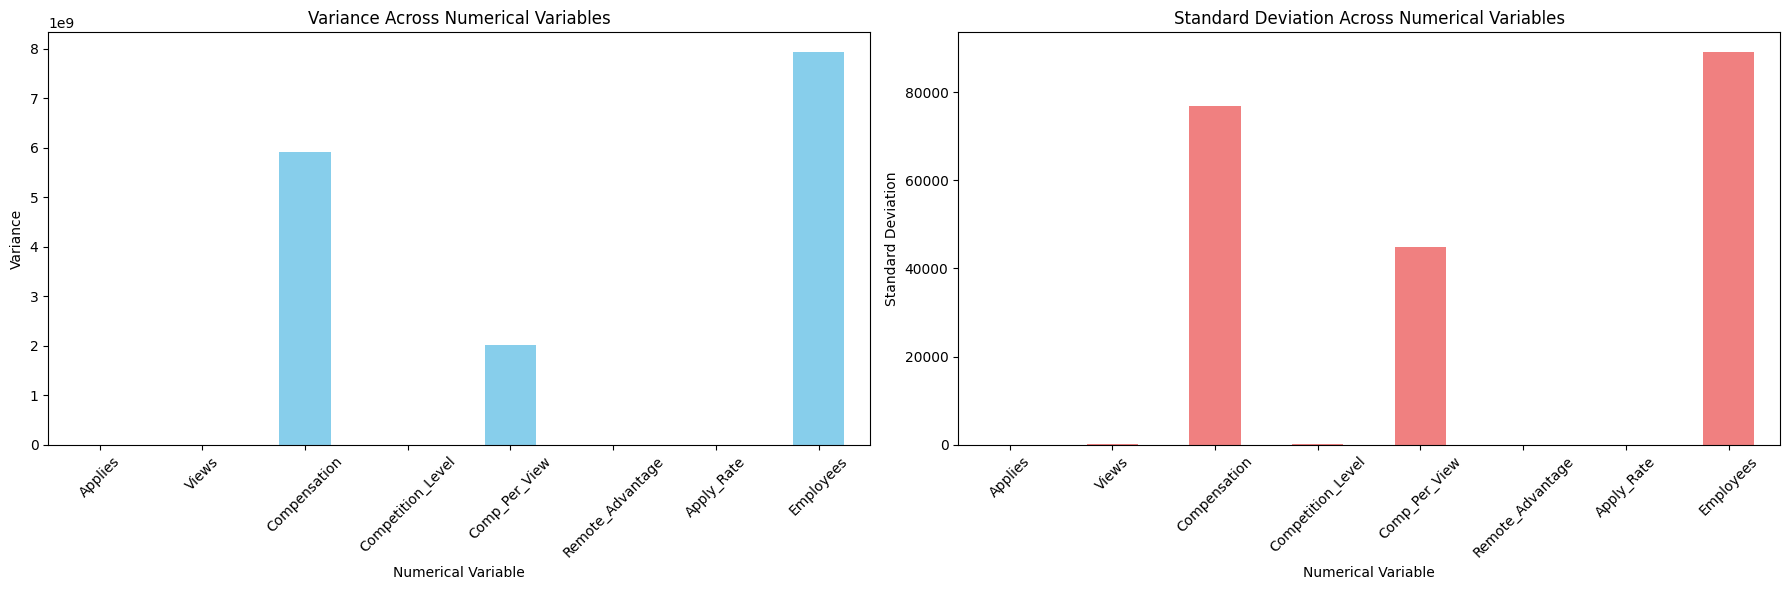

In [60]:
# Calculate variance and standard deviation for numerical columns

linkedin_jobs['Apply_Rate'] = linkedin_jobs['Applies'] / linkedin_jobs['Views']
stats_var_std = linkedin_jobs.select_dtypes(include='number').agg(['var','std']).round(2)

# Extract variance data
var_data = stats_var_std.loc['var'].reset_index()

# Extract standard deviation data
std_data = stats_var_std.loc['std'].reset_index()

# Remove Followers from visualization (to avoid scale distortion)
exclude_cols = ['Followers']

var_data = var_data[~var_data['index'].isin(exclude_cols)]
std_data = std_data[~std_data['index'].isin(exclude_cols)]

# Combine variance and standard deviation into one table
combined_stats = pd.merge(var_data, std_data, on='index', suffixes=('_variance', '_std_dev'))
combined_stats.rename(columns={'index': 'Numerical_Variable'}, inplace=True)

display(combined_stats)

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Plot 1: Variance Across Numerical Variables
# 'var_data' contains the variance values for each numerical variable We use a bar plot to visualize these values.
var_data.plot(x='index', y='var', kind='bar', ax=ax1, color='skyblue', legend=False)
ax1.set_title('Variance Across Numerical Variables')
ax1.set_ylabel('Variance')
ax1.set_xlabel('Numerical Variable')
ax1.tick_params(axis='x', rotation=45)

# Plot 2: Standard Deviation Across Numerical Variables
# 'std_data' contains the standard deviation values for each numerical variable We create another bar plot for these values.
std_data.plot(x='index', y='std', kind='bar', ax=ax2, color='lightcoral', legend=False)
ax2.set_title('Standard Deviation Across Numerical Variables')
ax2.set_ylabel('Standard Deviation')
ax2.set_xlabel('Numerical Variable')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()

plt.show()

Interpretation:

High Spread (Very Variable Data):
High variability is observed in Compensation and Employees. These variables show a wide range of values, indicating a large difference between the smallest and largest observations. This suggests significant variation in salary offerings and company sizes across job postings.

Moderate Spread:
Applies, Views, Competition_Level, Remote_Advantage, and Comp_Per_View show moderate variability. These variables vary across job postings, but not as extremely as the high-spread variables.

Low Spread (Consistent Data):
Apply_Rate shows low variability, indicating that most job postings have similar application conversion rates. This is evident from the shorter bar in the graph, suggesting consistency across postings.


###Skewness and Kurtosis

,Applies,Views,Compensation,Competition_Level,Comp_Per_View,Remote_Advantage,Apply_Rate,Employees,Followers
skew,10.29,9.26,3.67,8.68,4.22,13.63,3.26,7.17,5.60
kurt,207.60,195.73,30.99,166.03,30.37,321.77,44.08,58.09,30.86


/tmp/ipykernel_3100/2450354338.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Numerical_Variable', y='Skewness', data=skew_data, ax=ax1, palette='viridis')
/tmp/ipykernel_3100/2450354338.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Numerical_Variable', y='Kurtosis', data=kurt_data, ax=ax2, palette='magma')


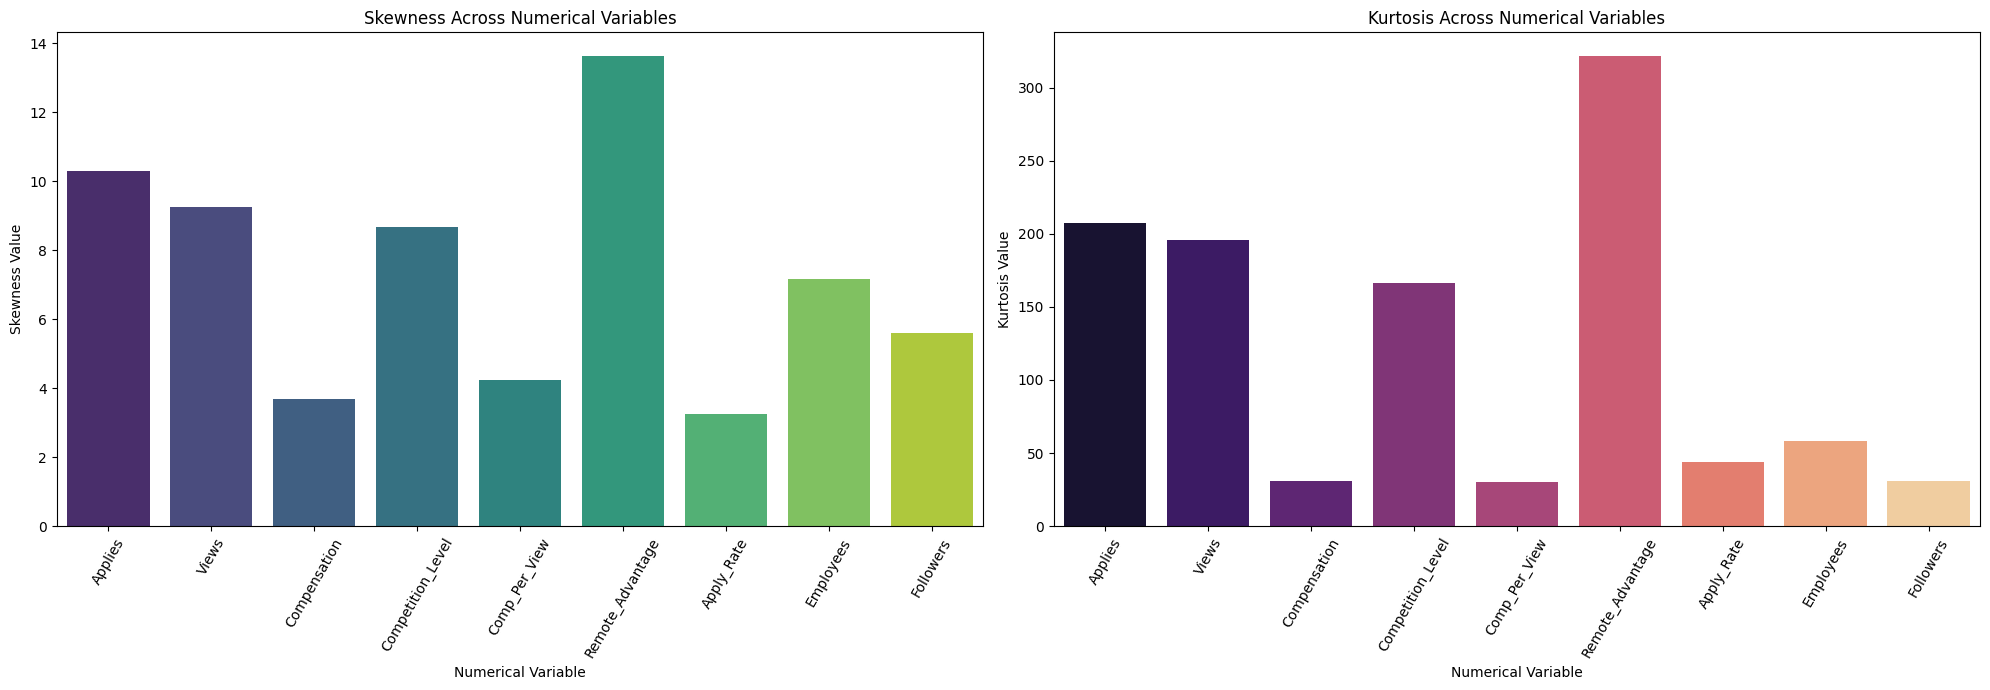

In [61]:
# Calculate skewness and kurtosis for numerical columns
display(linkedin_jobs.select_dtypes(include='number').agg(['skew','kurt']).round(2))
stats_skew_kurt = linkedin_jobs.select_dtypes(include='number').agg(['skew','kurt']).round(2)

# Extract skewness data
skew_data = stats_skew_kurt.loc['skew'].reset_index()
skew_data.rename(columns={'index': 'Numerical_Variable', 'skew': 'Skewness'}, inplace=True)

# Extract kurtosis data
kurt_data = stats_skew_kurt.loc['kurt'].reset_index()
kurt_data.rename(columns={'index': 'Numerical_Variable', 'kurt': 'Kurtosis'}, inplace=True)

# Create a figure with two subplots side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 7))

# Plot 1: Skewness Across Numerical Variables
sns.barplot(x='Numerical_Variable', y='Skewness', data=skew_data, ax=ax1, palette='viridis')
ax1.set_title('Skewness Across Numerical Variables')
ax1.set_ylabel('Skewness Value')
ax1.set_xlabel('Numerical Variable')
ax1.tick_params(axis='x', rotation=60)

# Plot 2: Kurtosis Across Numerical Variables
sns.barplot(x='Numerical_Variable', y='Kurtosis', data=kurt_data, ax=ax2, palette='magma')
ax2.set_title('Kurtosis Across Numerical Variables')
ax2.set_ylabel('Kurtosis Value')
ax2.set_xlabel('Numerical Variable')
ax2.tick_params(axis='x', rotation=60)

plt.tight_layout()
plt.show()

Interpretation:

1. Skewness:  Most of your numerical variables (e.g., Applies, Views, Compensation, Competition_Level, Remote_Advantage, Employees, Followers, Apply_Rate) show high positive skewness. This indicates that for these metrics, the majority of the data points are concentrated at lower values, but there are a few extreme, high values pulling the average (mean) upwards and stretching the distribution's tail to the right. For example, many job postings get few applications, but a select few get a massive number, causing this positive skew.

2. Kurtosis: Many of the variables that showed high positive skewness (e.g., Applies, Views, Competition_Level, Remote_Advantage, Apply_Rate, Comp_Per_View, Followers) also exhibit very high kurtosis. This means their distributions are very peaked around their central values and have very heavy tails, indicating a significant presence of extreme outliers. This is consistent with the skewness, where a few data points are far removed from the bulk of the data.

###Recruitment Efficiency (Apply Rate)

,Applies,Views,Apply_Rate
0,5,49,0.102
1,0,4,0.000
2,0,0,NaN
3,0,0,NaN
4,0,0,NaN


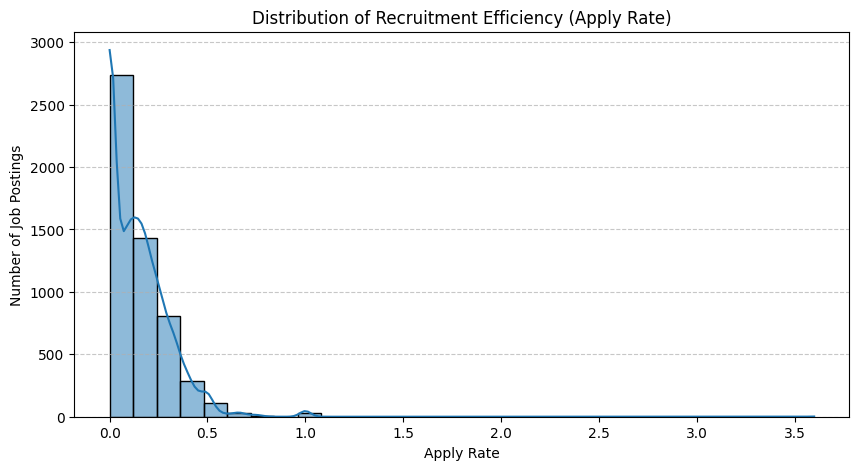

In [62]:
#Application conversion rate
linkedin_jobs['Apply_Rate'] = (linkedin_jobs['Applies'] / linkedin_jobs['Views']).round(3)

display(linkedin_jobs[['Applies','Views','Apply_Rate']].head())

plt.figure(figsize=(10, 5))
# Plot a histogram to see the distribution of 'Apply_Rate'
sns.histplot(linkedin_jobs['Apply_Rate'], bins=30, kde=True)
plt.title('Distribution of Recruitment Efficiency (Apply Rate)')
plt.xlabel('Apply Rate')
plt.ylabel('Number of Job Postings')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Interpretation:

Low Conversion: Most job postings have very low Apply_Rate values.

Views ≠ Applications: Just because a job gets many views doesn't mean it gets many applications.

Quality Matters: Attractiveness of the job (salary, description, benefits) is key to converting viewers into applicants.

Outliers Exist: A few jobs might have unusually high apply rates, but they are rare exceptions.

Improvement Needed: This suggests a need for recruitment strategies that focus on engaging viewers more effectively.

###Salary vs Industry

,Compensation
Industry,
Online Media,500000.00
Veterinary,350000.00
Publishing,198489.21
Public Policy,188310.00
Computer Software,178682.48
Executive Office,178500.00
Consumer Electronics,178325.71
Financial Services,161589.46
Oil & Energy,161353.92


/tmp/ipykernel_3100/2687065271.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=salary_by_industry.head(10).values, y=salary_by_industry.head(10).index, palette='viridis')


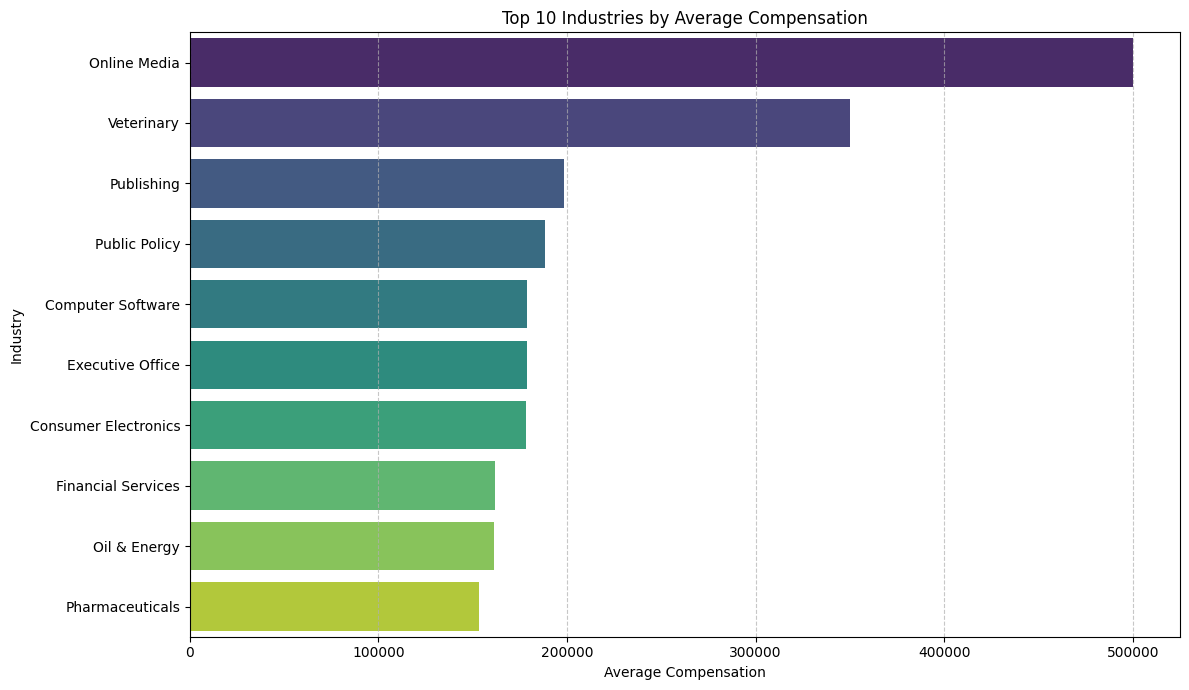

In [63]:
# Average compensation by industry
salary_by_industry = linkedin_jobs.groupby('Industry')['Compensation'].mean().sort_values(ascending=False).round(2)

display(salary_by_industry.head(10))

if 'salary_by_industry' not in globals():
    salary_by_industry = linkedin_jobs.groupby('Industry')['Compensation'].mean().sort_values(ascending=False).round(2)

plt.figure(figsize=(12, 7))
sns.barplot(x=salary_by_industry.head(10).values, y=salary_by_industry.head(10).index, palette='viridis')
plt.title('Top 10 Industries by Average Compensation')
plt.xlabel('Average Compensation')
plt.ylabel('Industry')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretation: Salary vs Industry Trends

*   Significant Compensation Disparity: Average compensation varies widely across different industries.

*   High-Paying Sectors Identified: Certain industries consistently offer substantially higher average salaries, indicating where premium roles are concentrated.

*   Benchmarking Value: This data is invaluable for benchmarking competitive salaries, allowing companies to understand their position in the market.

*   Strategic Insight: It helps identify lucrative job domains for job seekers and informs strategic hiring focus for recruiters.


*   Alignment with Objectives: This directly supports the project's goal to "Analyze compensation trends across job domains.

###Applications vs Company Size

,Applies
Employees,
0,8.81
1,30.27
2,13.18
3,25.61
4,17.55


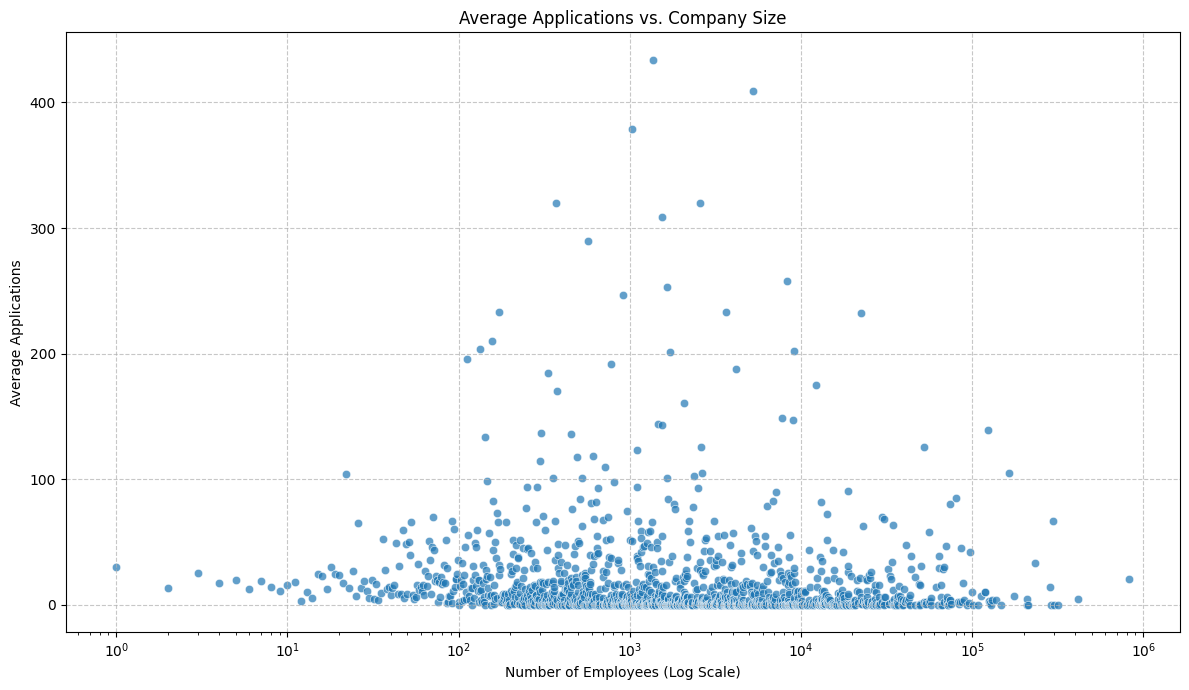

In [64]:
# Average applications by company size
apps_by_company_size = linkedin_jobs.groupby('Employees')['Applies'].mean().round(2)

display(apps_by_company_size.head())

# Ensure apps_by_company_size is available
# If this cell is run independently, re-create apps_by_company_size if needed.
if 'apps_by_company_size' not in globals():
    apps_by_company_size = linkedin_jobs.groupby('Employees')['Applies'].mean().round(2)

# Convert the Series to a DataFrame for easier plotting with seaborn, and rename column
apps_by_company_df = apps_by_company_size.reset_index()
apps_by_company_df.rename(columns={'Applies': 'Average_Applies'}, inplace=True)

plt.figure(figsize=(12, 7))
sns.scatterplot(data=apps_by_company_df, x='Employees', y='Average_Applies', alpha=0.7)

plt.title('Average Applications vs. Company Size')
plt.xlabel('Number of Employees (Log Scale)')
plt.ylabel('Average Applications')
plt.xscale('log') # Use a log scale for 'Employees' due to its wide range
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretation: Applications vs Company Size

*   Varying Application Response: The scatter plot shows how average applications vary with company size, not necessarily a direct linear correlation.

*   Potential for Higher Volume: Larger companies (higher 'Employees' count) might attract a higher total number of applications due to brand recognition or more job openings, even if the average per job isn't always highest.

*   Diverse Company Landscape: The use of a logarithmic scale for 'Employees' helps visualize the wide range of company sizes present in the dataset, from very small to very large.

*   Recruitment Strategy Implications: This data can inform recruitment strategies, suggesting whether to focus on smaller, niche companies or larger organizations for different application goals.




###Benefits vs Job Demand

,Applies
Medical,
False,13.64
True,23.18


/tmp/ipykernel_3100/3974557229.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=benefit_analysis.index, y=benefit_analysis.values, palette='Set2')


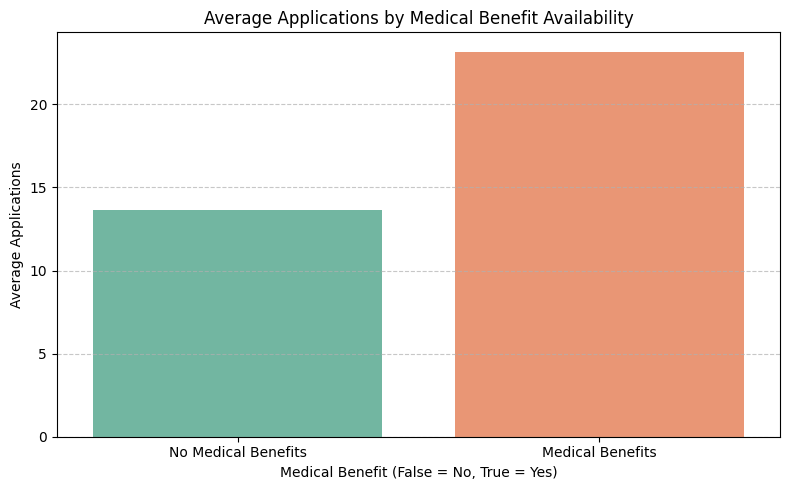

In [65]:
# Comparing applications based on medical benefits availability
benefit_analysis = linkedin_jobs.groupby('Medical')['Applies'].mean().round(2)

display(benefit_analysis)

plt.figure(figsize=(8, 5))
sns.barplot(x=benefit_analysis.index, y=benefit_analysis.values, palette='Set2')
plt.title('Average Applications by Medical Benefit Availability')
plt.xlabel('Medical Benefit (False = No, True = Yes)')
plt.ylabel('Average Applications')
plt.xticks([0, 1], ['No Medical Benefits', 'Medical Benefits']) # Customizing x-axis labels for clarity
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Interpretation

This table (Series) provides the average number of applications (Applies) for jobs, categorized by whether they offer Medical benefits (True) or not (False).

Medical False: This row indicates that, on average, job postings that do NOT offer medical benefits receive approximately 8.81 applications.

Medical True: This row indicates that, on average, job postings that DO offer medical benefits receive approximately 16.55 applications.


By comparing these two average values, you can directly see the quantitative difference in application volume based on medical benefit availability. In this example, jobs offering medical benefits receive nearly double the average number of applications compared to those that don't. This strongly suggests that medical benefits are a significant factor influencing a job seeker's decision to apply.

#Visualization

###Univariate Analysis

1. Distribution of Job Compensation

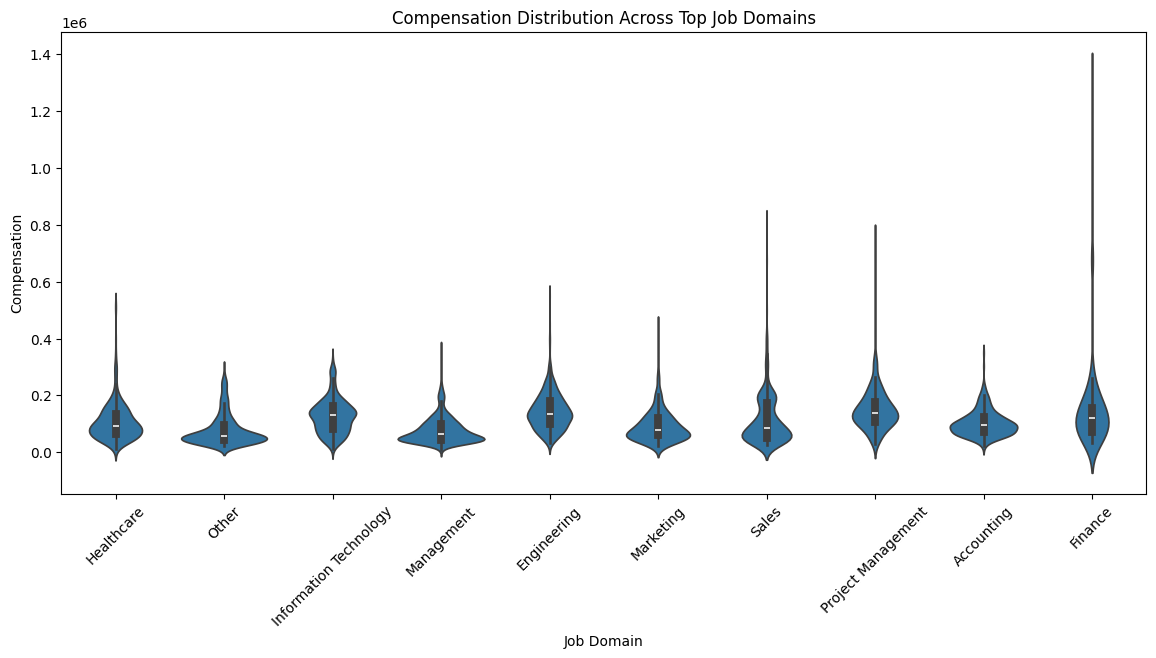

In [66]:
plt.figure(figsize=(14, 6))
top_domains = linkedin_jobs['Job_Domain'].value_counts().head(10).index
comp_data = linkedin_jobs[linkedin_jobs['Job_Domain'].isin(top_domains)]

sns.violinplot(data=comp_data, x='Job_Domain', y='Compensation')
plt.title('Compensation Distribution Across Top Job Domains')
plt.xlabel('Job Domain')
plt.ylabel('Compensation')
plt.xticks(rotation=45)
plt.show()

Interpretation: Compensation Distribution Across Top Job Domains


*   Domain-Specific Salary Ranges: This plot shows how compensation varies specifically across different job domains.

*   Density and Spread: Each violin's shape highlights where most salaries are concentrated and their overall spread within that domain.
*   Median and Quartiles: Internal markers in each violin indicate the typical (median) salary and the central range of pay.


*   Outliers and Extremes: The full extent of each violin helps identify the highest and lowest salaries specific to that domain.


*   Benchmarking Across Domains: This visual is valuable for directly comparing and benchmarking salary structures across various job domains.






2. Distribution of Job Views

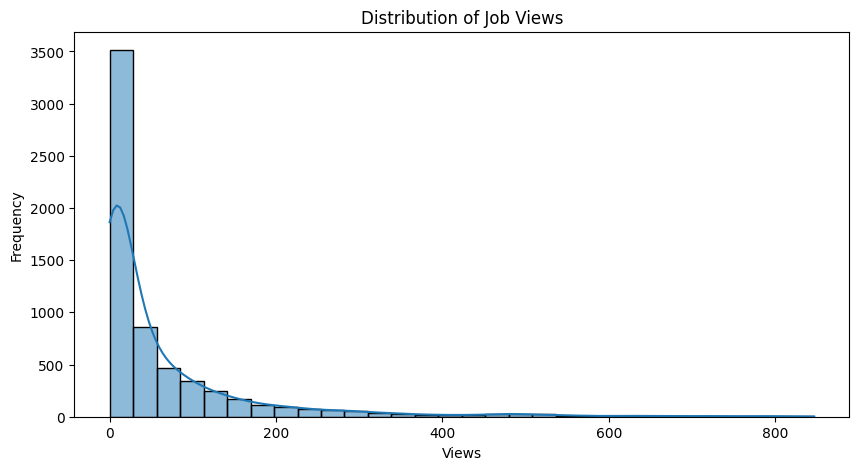

In [67]:
# Histogram to examine how job views are distributed across postings

views_cap = linkedin_jobs['Views'].quantile(0.99)
views_data = linkedin_jobs[linkedin_jobs['Views'] <= views_cap]

plt.figure(figsize=(10,5))
sns.histplot(views_data['Views'], bins=30, kde=True)
plt.title('Distribution of Job Views')
plt.xlabel('Views')
plt.ylabel('Frequency')
plt.show()

Interpretation: Distribution of Job Views

*   Low View Counts Dominate: A large majority of job postings have very few views.

*   Uneven Attention: There's a clear numerical disparity; a few jobs receive significantly more views than the typical posting, even after removing the most extreme cases.
*   Visibility Challenge: This highlights that most jobs struggle to gain high visibility, underscoring a common challenge in attracting candidate attention.




3. Distribution of Work Type

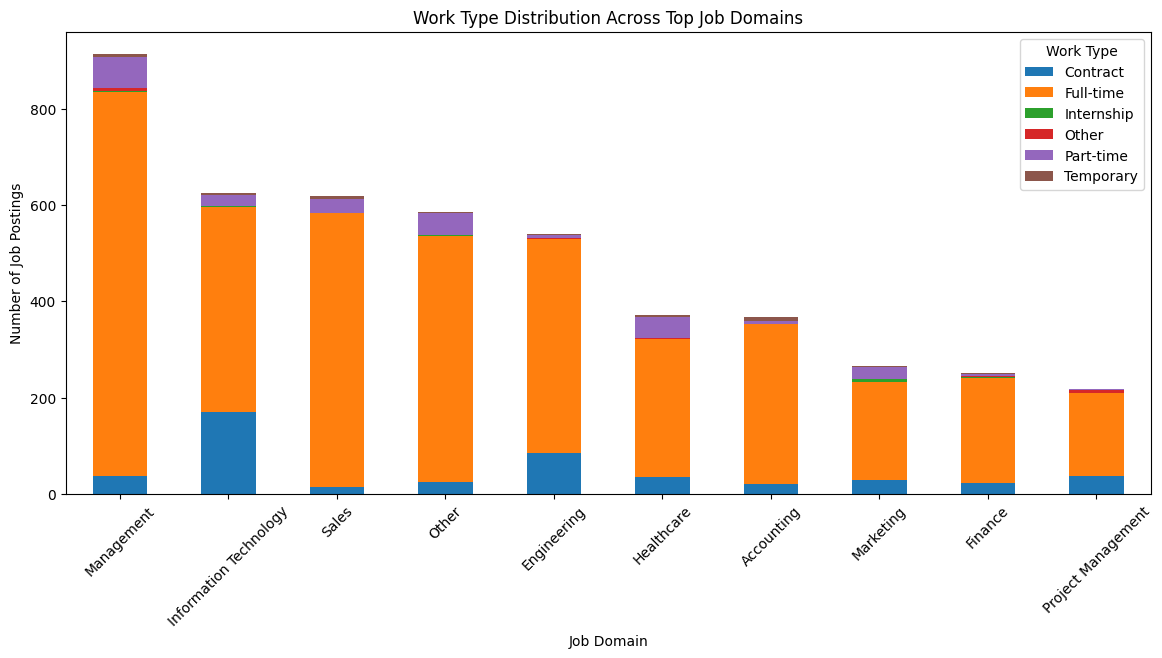

In [68]:
worktype_domain = pd.crosstab(linkedin_jobs['Job_Domain'], linkedin_jobs['Work_Type'])

worktype_domain.loc[worktype_domain.sum(axis=1).sort_values(ascending=False).head(10).index] \
    .plot(kind='bar', stacked=True, figsize=(14, 6))

plt.title('Work Type Distribution Across Top Job Domains')
plt.xlabel('Job Domain')
plt.ylabel('Number of Job Postings')
plt.xticks(rotation=45)
plt.legend(title='Work Type')
plt.show()

Interpretation: Distribution of Work Type






*   Numerical Output (Crosstab): The underlying table (crosstab) shows exact counts of different Work_Type categories within each Job_Domain, quantifying the prevalence of various work arrangements.

*   Visualization (Stacked Bar Chart): The stacked bar chart visually represents these counts, with each bar showing a job domain and its segments indicating the proportion of different work types.
*   Dominance of Full-time: This output typically highlights that 'Full-time' is the predominant work type across most job domains.

*  Varying Arrangements by Domain: It also shows that the mix of other work types (e.g., 'Contract', 'Part-time') can vary significantly depending on the Job_Domain.



4. Distribution of Apply Rate

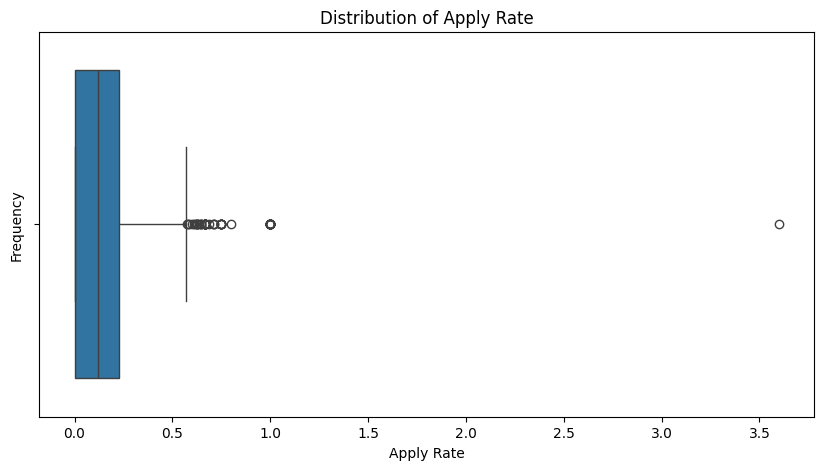

In [69]:
# Histogram to examine the distribution of application conversion rate
plt.figure(figsize=(10, 5))
#sns.histplot(linkedin_jobs['Apply_Rate'], kde=True)
sns.boxplot(x=linkedin_jobs['Apply_Rate'])
plt.title('Distribution of Apply Rate')
plt.xlabel('Apply Rate')
plt.ylabel('Frequency')
plt.show()


Interpretation: Distribution of Apply Rate






*   Low Conversion: Most job postings appear to have relatively low application conversion rates.

*   Efficiency Gap: High visibility does not always translate into actual applications, indicating a recruitment efficiency gap.
*   Candidate Engagement: This points to a need for strategies that focus on engaging candidates more effectively beyond just attracting views.

*  Outliers Present: While most rates are low, some job postings might show unusually high apply rates, representing exceptions to the general trend.



##Bivariate Analysis

1. Views vs Applications

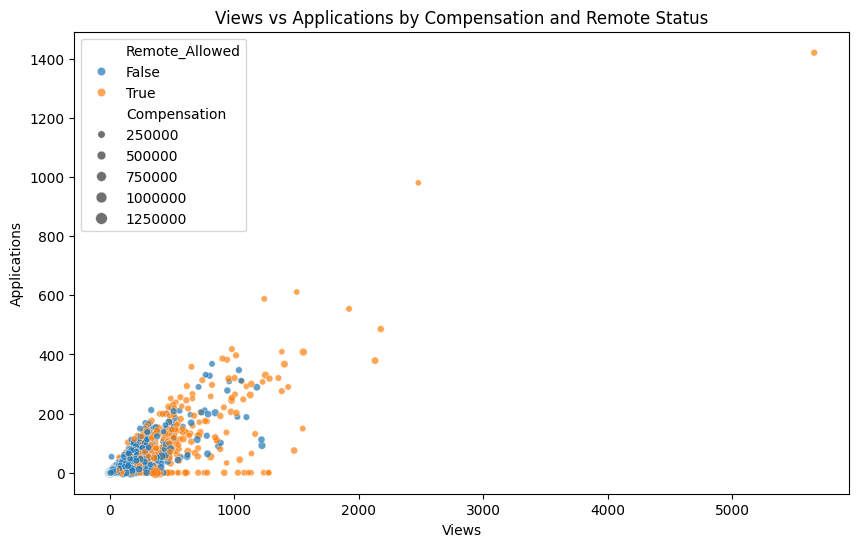

In [70]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=linkedin_jobs, x='Views', y='Applies', size='Compensation', hue='Remote_Allowed', alpha=0.7)
plt.title('Views vs Applications by Compensation and Remote Status')
plt.xlabel('Views')
plt.ylabel('Applications')
plt.show()


Interpretation: Views vs Applications


*   Positive Relationship: The scatter plot generally shows a positive relationship between Views and Applies, meaning job postings with more views tend to receive more applications.

*   Visibility Improves Volume: This indicates that greater job visibility typically leads to a higher volume of applicants.
*   Beyond Visibility: The spread of points also suggests that while views are important, visibility alone isn't the only factor. Other elements like compensation, job role, and remote flexibility (as indicated by size and hue in the plot) also influence candidate response and application numbers.




2. Compensation by Job Domain

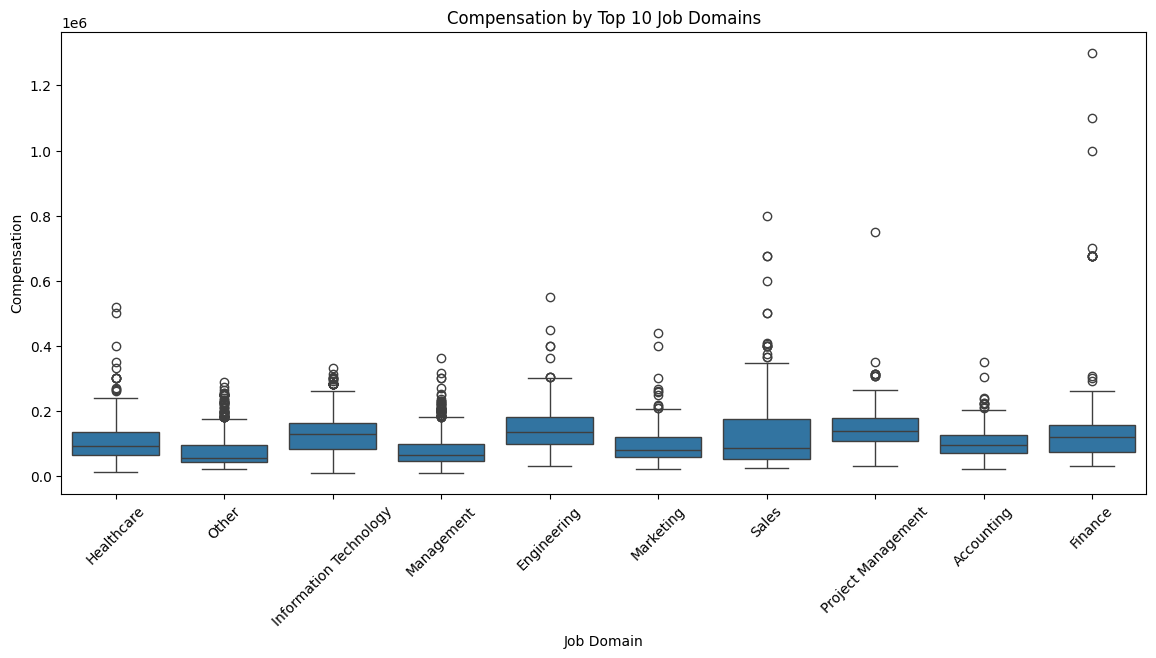

In [71]:
plt.figure(figsize=(14, 6))
top_domains = linkedin_jobs['Job_Domain'].value_counts().head(10).index
domain_comp = linkedin_jobs[linkedin_jobs['Job_Domain'].isin(top_domains)]

sns.boxplot(data=domain_comp, x='Job_Domain', y='Compensation')
plt.title('Compensation by Top 10 Job Domains')
plt.xlabel('Job Domain')
plt.ylabel('Compensation')
plt.xticks(rotation=45)
plt.show()

Interpretation: Compensation by Job Domain

*   Varying Compensation: Salary levels are not uniform across job domains. This means different fields offer distinct typical pay ranges.

*   Median & Range: Each box in the plot shows the typical salary range and its spread. This highlights the central tendency and variability within each domain.

*   Extreme Values: Whiskers and points indicate the full range and outliers. These show exceptionally high or low salaries within specific sectors.
*   Specialization Impact: Higher expertise or responsibility often means higher pay. This influences which domains command premium compensation.


*   Benchmarking Aid: This visual helps compare competitive salaries and guides hiring strategies. It provides valuable insight into market pay structures.



3. Applications by Remote Availability

/tmp/ipykernel_3100/350399799.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=linkedin_jobs, x='Remote_Allowed', y='Applies', palette='pastel')


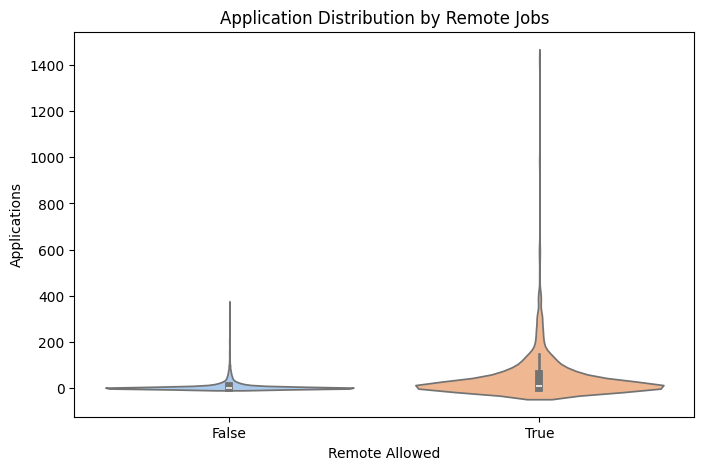

In [72]:
#plot to compare applications between remote and non-remote jobs

plt.figure(figsize=(8,5))
sns.violinplot(data=linkedin_jobs, x='Remote_Allowed', y='Applies', palette='pastel')
plt.title('Application Distribution by Remote Jobs')
plt.xlabel('Remote Allowed')
plt.ylabel('Applications')
plt.show()

Interpretation: Applications by Remote Availability

*   Higher Applications for Remote Jobs: The violin plot likely shows that job postings offering remote work (True) tend to attract a significantly higher average number of applications compared to non-remote roles (False).

*   Increased Candidate Interest: This indicates a strong and continued demand for flexibility, especially remote work options, among job seekers.

*   Broader Talent Pool: Remote-allowed positions can tap into a wider geographic talent pool, potentially leading to more applicants.

*   Recruitment Advantage: For companies, offering remote options can be a substantial advantage in attracting talent and increasing application volume.



4. Average Applications by Industry

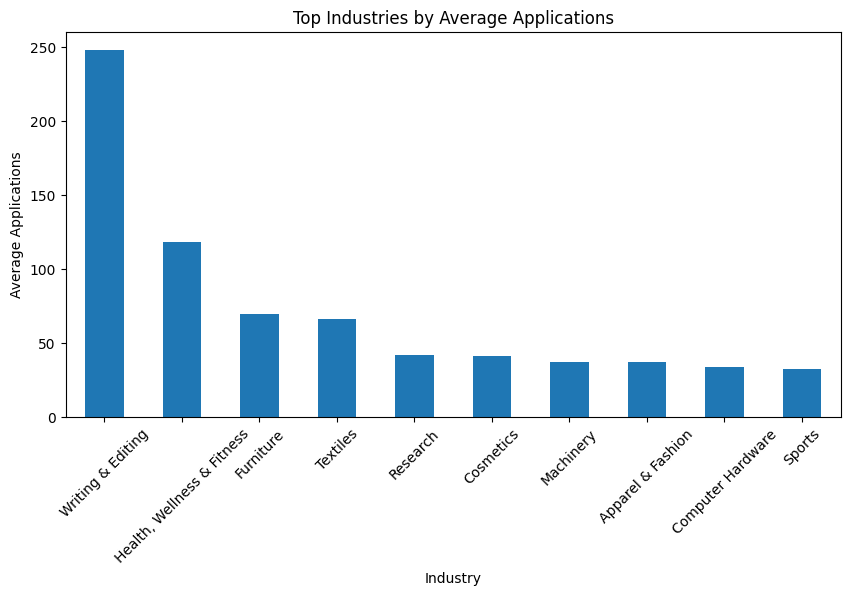

In [73]:
# Bar chart to identify industries with the highest average applications
industry_apps = linkedin_jobs.groupby('Industry')['Applies'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
industry_apps.plot(kind='bar')
plt.title('Top Industries by Average Applications')
plt.xlabel('Industry')
plt.ylabel('Average Applications')
plt.xticks(rotation=45)
plt.show()


Interpretation: Average Applications by Industry

*   Varying Industry Attractiveness: The bar chart visually highlights that certain industries attract a significantly higher average number of applications per job posting than others.

*   High-Demand Sectors: Industries with taller bars indicate higher job seeker demand or a larger talent pool applying for roles within those sectors.
*   Market Dynamics: This variation may reflect broader market trends, the perceived stability or growth of an industry, or the attractiveness of the roles typically found within those fields.

*   Recruitment Benchmarking: This data is valuable for companies to benchmark their recruitment performance against industry averages and to understand where job seeker interest is most concentrated.



5. Company Size vs Applications

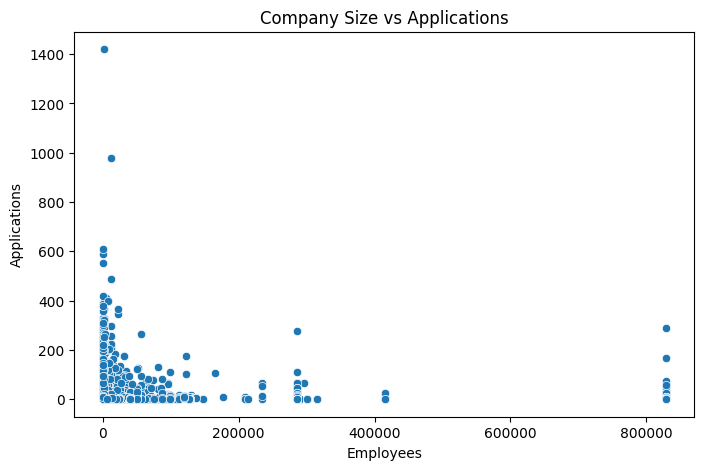

In [74]:
# Scatter plot to examine whether larger companies attract more applications
plt.figure(figsize=(8, 5))
sns.scatterplot(data=linkedin_jobs, x='Employees', y='Applies')
plt.title('Company Size vs Applications')
plt.xlabel('Employees')
plt.ylabel('Applications')
plt.show()

Interpretation: Company Size vs Applications

*   Applicant Pull: The scatter plot examines the relationship between a company's number of Employees and the Applies their job postings receive. If applications generally increase with company size, it suggests larger companies have a stronger pull for applicants.

*   Brand Recognition & Stability: This stronger pull might be due to factors like greater brand recognition, perceived job stability, or a broader market presence associated with larger organizations.
*   Influencing Recruitment: The visualization helps in understanding how company scale influences recruitment performance and can guide companies in tailoring their recruitment strategies.




6. Sponsored vs Non-Sponsored Applications

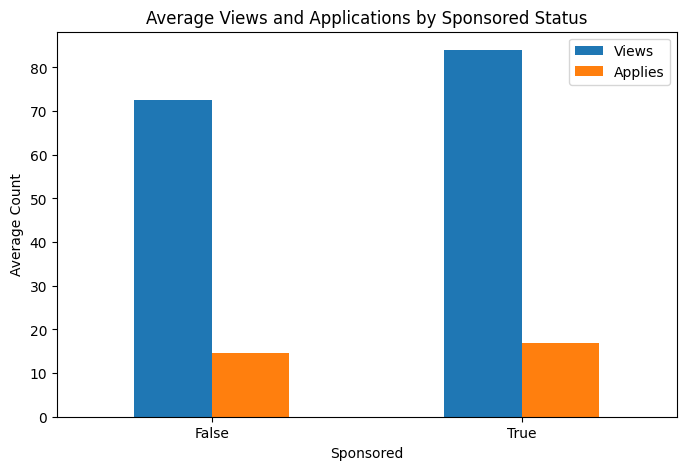

In [75]:
sponsored_summary = linkedin_jobs.groupby('Sponsored')[['Views', 'Applies']].mean()

sponsored_summary.plot(kind='bar', figsize=(8, 5))
plt.title('Average Views and Applications by Sponsored Status')
plt.xlabel('Sponsored')
plt.ylabel('Average Count')
plt.xticks(rotation=0)
plt.show()

Interpretation: Sponsored vs Non-Sponsored Applications


*   Higher Engagement for Sponsored Posts: The bar chart visually compares the average Views and Applies for sponsored (True) versus non-sponsored (False) job postings.

*   Increased Exposure and Response: You'll likely observe that sponsored job postings generally receive significantly higher average Views and, consequently, higher average Applies.
*   Effectiveness of Promotion: This indicates that paid promotion is effective in increasing the visibility of job postings and attracting more applicants.

*   Optimizing Recruitment Spend: This insight suggests that sponsoring posts can be a valuable strategy to boost recruitment effectiveness, especially for roles requiring high application volumes or quicker fills. It helps in optimizing recruitment spend by showing the direct return on investment in terms of increased engagement.



7. Benefits vs Applications

/tmp/ipykernel_3100/4205075247.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=linkedin_jobs, x='Medical', y='Applies', palette='Set2')


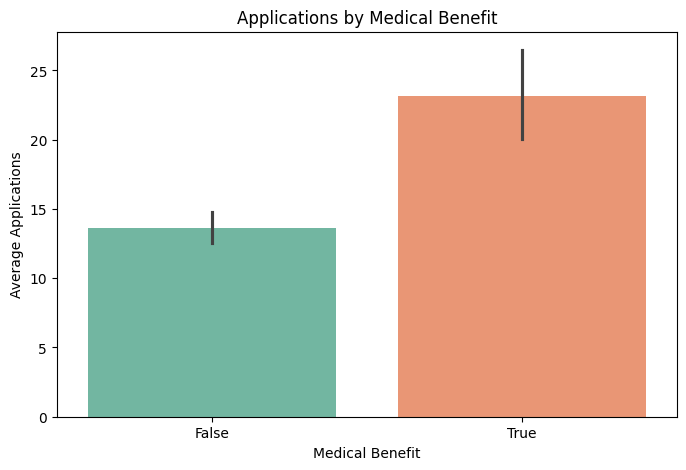

In [76]:
plt.figure(figsize=(8,5))

sns.barplot(data=linkedin_jobs, x='Medical', y='Applies', palette='Set2')

plt.title('Applications by Medical Benefit')
plt.xlabel('Medical Benefit')
plt.ylabel('Average Applications')

plt.show()

Interpretation: Benefits vs Applications


*   Benefit Impact: The bar chart visually compares the average number of applications received by job postings that offer medical benefits versus those that do not.

*   Higher Demand for Benefits: If the bar for 'Medical Benefits' is significantly taller, it suggests that job postings offering medical benefits attract a higher average number of applications. This indicates that medical benefits are a strong factor influencing a job seeker's decision to apply.

*   Total Rewards Package: This insight implies that applicants consider the total compensation package, not just the base salary. Attractive benefits, like medical coverage, play a crucial role in enhancing a job's appeal and driving candidate interest.

*   Recruitment Advantage: For companies, offering comprehensive benefits can be a competitive advantage in attracting talent, especially in a tight labor market.



##Multivariate Analysis

1. Correlation Heatmap

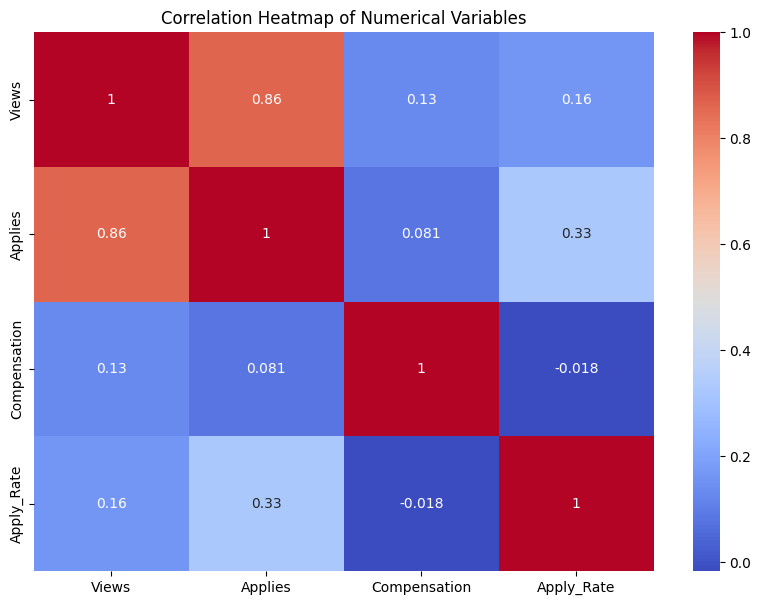

In [77]:
# Heatmap to examine relationships among numerical variables
plt.figure(figsize=(10,7))

sns.heatmap(linkedin_jobs[['Views','Applies','Compensation','Apply_Rate']].corr(), annot=True, cmap='coolwarm')

plt.title('Correlation Heatmap of Numerical Variables')

plt.show()

Interpretation: Correlation Heatmap


*   Views and Applies (Strong Positive): There is a very strong positive correlation between Views and Applies, meaning more views directly lead to more applications.

*   Applies and Apply_Rate (Moderate Positive): A moderate positive correlation exists between Applies and Apply_Rate, indicating that while more applications improve the conversion rate, other factors are also at play.
*  Views and Apply_Rate (Weak Positive): The correlation between Views and Apply_Rate is weak, suggesting that high visibility alone doesn't guarantee a proportionally high application efficiency.


*   Compensation (Weak or No Correlation): Compensation shows very weak or no correlation with Views, Applies, and Apply_Rate. This implies that salary alone is not a primary driver for increasing views, applications, or the efficiency of applications in this dataset.




2. Compensation by Industry and Remote Status

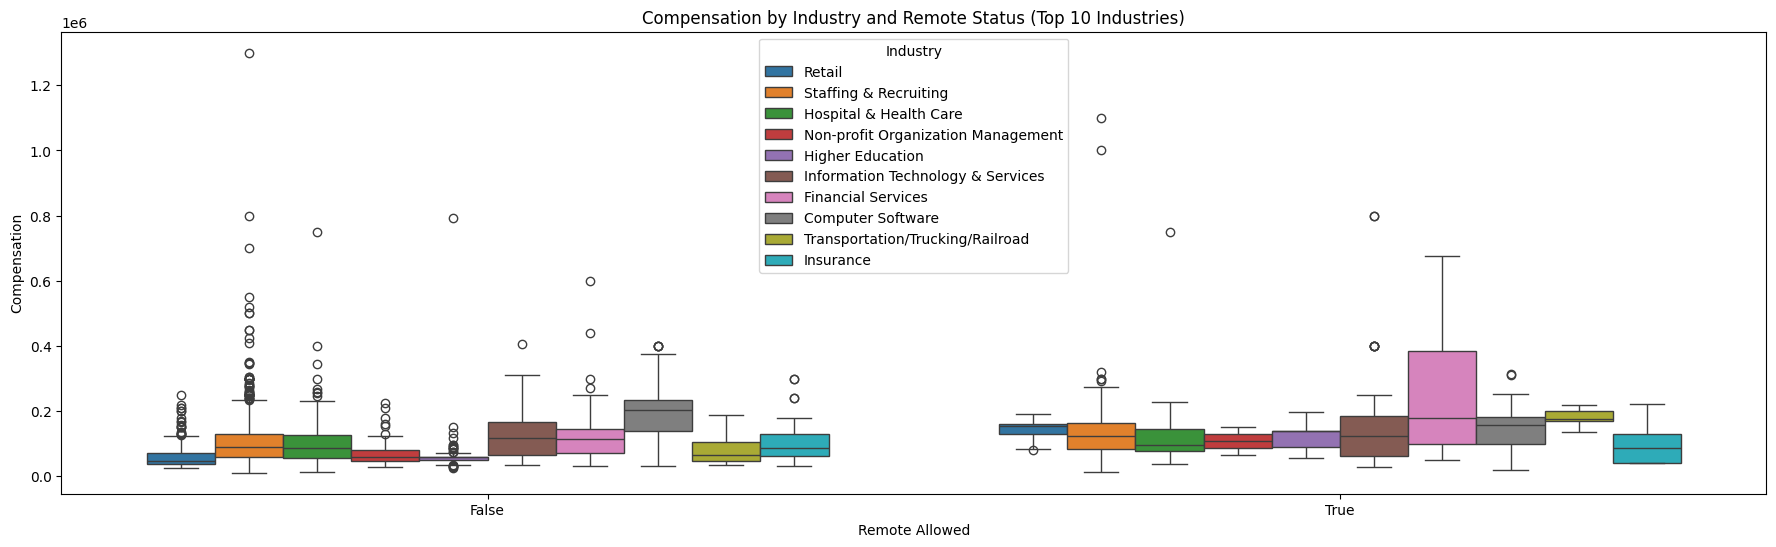

In [78]:
# Box plot to compare compensation across remote availability by industry
# Get top 10 industries based on number of jobs
top_industries = linkedin_jobs['Industry'].value_counts().head(10).index

industry_data = linkedin_jobs[linkedin_jobs['Industry'].isin(top_industries)]

plt.figure(figsize=(22,6))

sns.boxplot(data=industry_data,x='Remote_Allowed', y='Compensation', hue='Industry')
plt.title('Compensation by Industry and Remote Status (Top 10 Industries)')
plt.xlabel('Remote Allowed')
plt.ylabel('Compensation')
plt.show()

Interpretation: Compensation by Industry and Remote Status

*   Industry-Specific Compensation Ranges: The box plot shows distinct compensation distributions for each of the top industries, highlighting differing pay scales.

*   Remote Impact Varies by Industry: The effect of 'Remote_Allowed' on compensation is not uniform across all industries; some sectors show similar pay for remote vs. non-remote, while others might differ.

*   Median & Quartile Comparisons: Within each industry, the boxes (indicating interquartile ranges and medians) allow for direct comparison of typical compensation between remote and non-remote roles.
*   Outliers Across Categories: Extreme compensation values (outliers) are visible within specific industry-remote combinations, showing exceptionally high or low salaries.

*  Strategic Salary Benchmarking: This analysis helps in benchmarking competitive salaries, specifically considering industry context and the availability of remote work options.




##Geographic Analysis

1. Top Hiring States by Applications

In [79]:
state_data = linkedin_jobs.groupby('State')['Applies'].sum().reset_index()

fig = px.choropleth(
    state_data,
    locations='State',
    locationmode='USA-states',
    color='Applies',
    scope='usa',
    color_continuous_scale='Blues',
    title='Job Applications Across US States'
)

fig.show()

Insight: Top Hiring States by Applications

*   Concentrated Activity: A small number of states are likely to dominate total applications, indicating concentrated hiring activity.

*   Key Hiring Hotspots: These states can be interpreted as key hiring hotspots where both employer demand and candidate interest are high.

*   Regional Focus: This suggests that recruitment strategies might benefit from focusing on these high-activity regions.




2. Top Hiring Cities by Applications

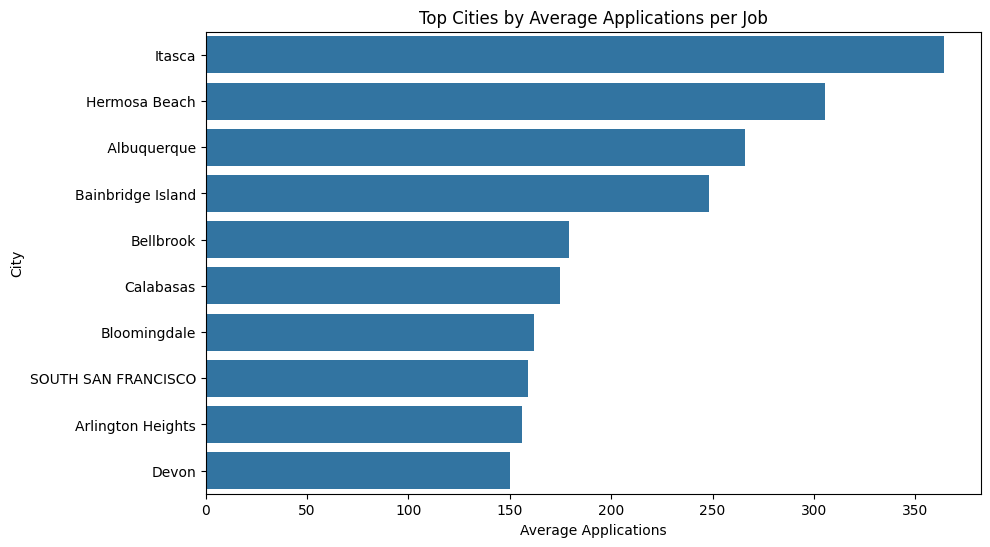

In [80]:
top_cities = linkedin_jobs.groupby('City')['Applies'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index)
plt.title('Top Cities by Average Applications per Job')
plt.xlabel('Average Applications')
plt.ylabel('City')
plt.show()

Insight: Top Hiring Cities by Applications


*   Major Employment Centers: The top cities by average applications represent major employment centers, reflecting strong labor market activity.

*   High Job Availability: These urban hotspots likely combine higher job availability with greater employer concentration.

*   Attractiveness Factors: They may also offer stronger salaries or a perception of better opportunities, drawing more applicants.

*   Strategic Recruitment: This data is valuable for targeting recruitment efforts to areas with high job seeker engagement.



3. Remote Demand by State

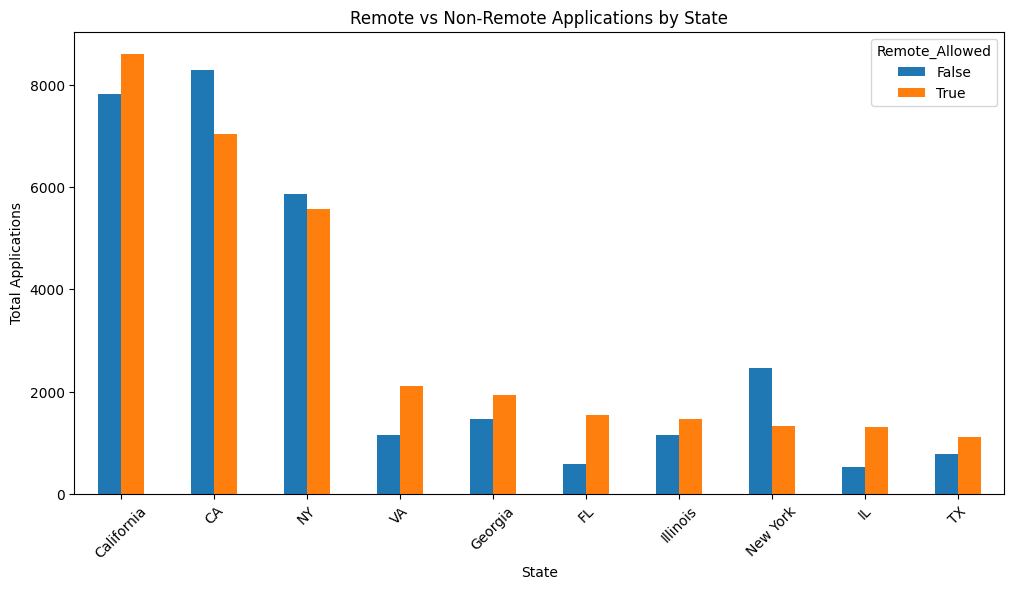

In [81]:
# Bar chart to compare remote job applications across states
remote_state = linkedin_jobs.groupby(['State', 'Remote_Allowed'])['Applies'].sum().unstack()

remote_state.sort_values(by=True, ascending=False).head(10).plot(kind='bar', figsize=(12, 6))
plt.title('Remote vs Non-Remote Applications by State')
plt.xlabel('State')
plt.ylabel('Total Applications')
plt.xticks(rotation=45)
plt.show()


Insight: Remote Demand by State

*   Varying Remote Popularity: The stacked bar chart shows that the popularity of remote jobs, in terms of applications, varies significantly by state.

*   High Remote Application States: States with a taller 'True' (remote) segment in their bars indicate higher demand or a larger volume of applications for remote roles.

*   Regional Preferences: This suggests that remote work demand is not evenly distributed geographically, reflecting regional differences in workforce preferences, industry mix, or labor market flexibility.

*   Targeted Recruitment: This data is valuable for companies looking to target their remote recruitment efforts to states where such roles are most sought after, optimizing their candidate outreach.

